# League of Legends Meta Analysis - Machine Learning

## Projet d'analyse de la méta et prédiction de victoire

**Objectif** : Maximiser les chances de victoire dans League of Legends en s'appuyant sur l'analyse des données et des modèles de machine learning.

**Approche** : 
- Analyser la méta actuelle (champions, items)
- Optimiser les builds et performances
- Développer des stratégies de draft (picks/bans)
- Prédire l'issue des parties

---

Ce notebook suit le plan d'action détaillé et implémente chaque phase progressivement.

# Phase 0 - Préparation et Qualité des Données

## Objectifs de cette phase :
1. **Rassembler et contrôler** : Charger tous les fichiers CSV du dataset
2. **Nettoyer** : Gérer valeurs manquantes, données corrompues etc.
3. **Échantillonner** : Conserver uniquement les modes **CLASSIC** et **ARAM** (exclure les autres)

**Pourquoi cette phase est cruciale ?**
- La qualité des données impacte directement la fiabilité des modèles
- Un nettoyage rigoureux évite les biais et erreurs de prédiction

## 0.1 - Import des bibliothèques

**Bibliothèques nécessaires :**
- **pandas** : Manipulation et analyse de données tabulaires
- **numpy** : Calculs numériques et opérations sur tableaux
- **matplotlib/seaborn** : Visualisations statistiques
- **sklearn** : Préparation des données et modélisation ML

In [1]:
# Import des bibliothèques essentielles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliothèques importées avec succès!")
print(f"Version pandas: {pd.__version__}")
print(f"Version numpy: {np.__version__}")

Bibliothèques importées avec succès!
Version pandas: 2.3.3
Version numpy: 2.4.0


## 0.2 - Chargement des données

**Structure du dataset :**
- **ChampionTbl.csv** : Table de référence des champions
- **ItemTbl.csv** : Table de référence des items
- **RankTbl.csv** : Table de référence des rangs
- **MatchTbl.csv** : Table des matchs
- **SummonerMatchTbl.csv** : Association joueur-match-champion
- **MatchStatsTbl.csv** : Statistiques détaillées par joueur
- **TeamMatchTbl.csv** : Statistiques par équipe

In [2]:
# Définir le chemin vers le dataset
dataset_path = Path("../Dataset")
print("🔄 Chargement des tables...")

# Tables de référence (lookup tables)
champions_df = pd.read_csv(dataset_path / "ChampionTbl.csv")
items_df = pd.read_csv(dataset_path / "ItemTbl.csv")
ranks_df = pd.read_csv(dataset_path / "RankTbl.csv")

# Tables de faits (fact tables)
matches_df = pd.read_csv(dataset_path / "MatchTbl.csv")
summoner_match_df = pd.read_csv(dataset_path / "SummonerMatchTbl.csv")
match_stats_df = pd.read_csv(dataset_path / "MatchStatsTbl.csv")
team_match_df = pd.read_csv(dataset_path / "TeamMatchTbl.csv")

print("✅ Toutes les tables chargées!\n")

# Filtrer pour ne garder que les modes CLASSIC et ARAM
print("🎮 Filtrage des modes de jeu: conservation de CLASSIC et ARAM uniquement")
allowed_modes = ["CLASSIC", "ARAM"]
matches_df = matches_df[matches_df["QueueType"].isin(allowed_modes)].copy()

# Construire le set des MatchIds conservés et cascade sur les autres tables
allowed_match_ids = set(matches_df["MatchId"].values)

def filter_by_match_ids(df):
    if "MatchFk" in df.columns:
        return df[df["MatchFk"].isin(allowed_match_ids)].copy()
    elif "MatchId" in df.columns:
        return df[df["MatchId"].isin(allowed_match_ids)].copy()
    else:
        return df

summoner_match_df = filter_by_match_ids(summoner_match_df)
match_stats_df = filter_by_match_ids(match_stats_df)
team_match_df = filter_by_match_ids(team_match_df)

print(f"MatchTbl conservé: {len(matches_df):,} lignes")
print(f"SummonerMatchTbl conservé: {len(summoner_match_df):,} lignes")
print(f"MatchStatsTbl conservé: {len(match_stats_df):,} lignes")
print(f"TeamMatchTbl conservé: {len(team_match_df):,} lignes\n")

# Afficher les dimensions
tables = {
    "Champions": champions_df,
    "Items": items_df,
    "Ranks": ranks_df,
    "Matches": matches_df,
    "SummonerMatch": summoner_match_df,
    "MatchStats": match_stats_df,
    "TeamMatch": team_match_df
}

print("📊 Dimensions des tables:")
print("-" * 50)
for name, df in tables.items():
    print(f"{name:20} : {df.shape[0]:>8} lignes × {df.shape[1]:>2} colonnes")
    
print(f"\n💾 Mémoire totale utilisée: {sum(df.memory_usage(deep=True).sum() for df in tables.values()) / 1024**2:.2f} MB")

🔄 Chargement des tables...
✅ Toutes les tables chargées!

🎮 Filtrage des modes de jeu: conservation de CLASSIC et ARAM uniquement
MatchTbl conservé: 129,543 lignes
SummonerMatchTbl conservé: 262,756 lignes
MatchStatsTbl conservé: 303,512 lignes
TeamMatchTbl conservé: 116,686 lignes

📊 Dimensions des tables:
--------------------------------------------------
Champions            :      173 lignes ×  3 colonnes
Items                :      635 lignes ×  2 colonnes
Ranks                :       11 lignes ×  2 colonnes
Matches              :   129543 lignes ×  5 colonnes
SummonerMatch        :   262756 lignes ×  4 colonnes
MatchStats           :   303512 lignes × 31 colonnes
TeamMatch            :   116686 lignes × 24 colonnes

💾 Mémoire totale utilisée: 163.04 MB


## 0.3 - Exploration initiale des données

**Objectif :** Comprendre la structure, les types de données et détecter les premières anomalies.

**Ce que nous allons vérifier :**
- Types de données de chaque colonne
- Valeurs manquantes (NaN)
- Valeurs uniques et distribution
- Cohérence des clés étrangères

In [3]:
# Fonction helper pour explorer une table
def explore_table(df, name):
    print(f"\n{'='*60}")
    print(f"📋 TABLE: {name}")
    print('='*60)
    
    # Aperçu
    print("\n🔍 Aperçu des premières lignes:")
    display(df.head(5))
    
    # Informations sur les colonnes
    print(f"\n📊 Informations sur les colonnes:")
    print(df.info())
    
    # Valeurs manquantes
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n⚠️  Valeurs manquantes détectées:")
        print(missing[missing > 0])
    else:
        print(f"\n✅ Aucune valeur manquante détectée")
    
    return df

# Explorer les tables de référence (plus petites)
print("="*60)
print("🔎 EXPLORATION DES TABLES DE RÉFÉRENCE")
print("="*60)

explore_table(champions_df, "ChampionTbl")
explore_table(items_df, "ItemTbl") 
explore_table(ranks_df, "RankTbl")

🔎 EXPLORATION DES TABLES DE RÉFÉRENCE

📋 TABLE: ChampionTbl

🔍 Aperçu des premières lignes:


,ChampionId,ChampionName,ChampionLane
0,0,No Champion,NONE
1,1,Annie,MID
2,2,Olaf,JUNGLE
3,3,Galio,MID
4,4,TwistedFate,MID



📊 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ChampionId    173 non-null    int64 
 1   ChampionName  173 non-null    object
 2   ChampionLane  173 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.2+ KB
None

✅ Aucune valeur manquante détectée

📋 TABLE: ItemTbl

🔍 Aperçu des premières lignes:


,ItemID,ItemName
0,1001,Boots
1,1004,Faerie Charm
2,1006,Rejuvenation Bead
3,1011,Giant's Belt
4,1018,Cloak of Agility



📊 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ItemID    635 non-null    int64 
 1   ItemName  635 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.1+ KB
None

✅ Aucune valeur manquante détectée

📋 TABLE: RankTbl

🔍 Aperçu des premières lignes:


,RankId,RankName
0,0,Unranked
1,1,Iron
2,2,Bronze
3,3,Silver
4,4,Gold



📊 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   RankId    11 non-null     int64 
 1   RankName  11 non-null     object
dtypes: int64(1), object(1)
memory usage: 308.0+ bytes
None

✅ Aucune valeur manquante détectée


,RankId,RankName
0,0,Unranked
1,1,Iron
2,2,Bronze
3,3,Silver
4,4,Gold
5,5,Platinum
6,6,Emerald
7,7,Diamond
8,8,Master
9,9,Grandmaster


In [4]:
# Explorer MatchTbl (table centrale)
print("\n" + "="*60)
print("🔎 EXPLORATION DE LA TABLE CENTRALE DES MATCHS")
print("="*60)

explore_table(matches_df, "MatchTbl")

# Analyses spécifiques pour MatchTbl
print("\n📊 Analyses complémentaires pour MatchTbl:")
print("-" * 60)

# Distribution des types de queue
print("\n🎮 Distribution des modes de jeu:")
print(matches_df['QueueType'].value_counts())

# Distribution des ranks
print("\n🏆 Distribution des ranks:")
rank_dist = matches_df['RankFk'].value_counts().sort_index()
print(rank_dist)

# Statistiques sur les patches
print("\n🔧 Statistiques sur les patches:")
print(f"Nombre de patches différents: {matches_df['Patch'].nunique()}")
print("\nTop 10 patches les plus fréquents:")
print(matches_df['Patch'].value_counts().head(10))

# Durée des matchs
print("\n⏱️  Statistiques sur la durée des matchs:")
print(f"Durée min: {matches_df['GameDuration'].min()} sec ({matches_df['GameDuration'].min()/60:.1f} min)")
print(f"Durée max: {matches_df['GameDuration'].max()} sec ({matches_df['GameDuration'].max()/60:.1f} min)")
print(f"Durée moyenne: {matches_df['GameDuration'].mean():.0f} sec ({matches_df['GameDuration'].mean()/60:.1f} min)")
print(f"Durée médiane: {matches_df['GameDuration'].median():.0f} sec ({matches_df['GameDuration'].median()/60:.1f} min)")


🔎 EXPLORATION DE LA TABLE CENTRALE DES MATCHS

📋 TABLE: MatchTbl

🔍 Aperçu des premières lignes:


,MatchId,Patch,QueueType,RankFk,GameDuration
0,EUN1_3707659547,14.23.636.9832,ARAM,0,1173
1,EUN1_3709211408,14.24.642.1879,CLASSIC,0,1986
2,EUN1_3710823249,14.24.643.5128,ARAM,0,813
3,EUN1_3710849604,14.24.643.5128,ARAM,0,1070
4,EUN1_3710885279,14.24.643.5128,ARAM,0,968



📊 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
Index: 129543 entries, 0 to 149862
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   MatchId       129543 non-null  object
 1   Patch         129543 non-null  object
 2   QueueType     129543 non-null  object
 3   RankFk        129543 non-null  int64 
 4   GameDuration  129543 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 5.9+ MB
None

✅ Aucune valeur manquante détectée

📊 Analyses complémentaires pour MatchTbl:
------------------------------------------------------------

🎮 Distribution des modes de jeu:
QueueType
CLASSIC    113280
ARAM        16263
Name: count, dtype: int64

🏆 Distribution des ranks:
RankFk
0     12372
1      1907
2      3756
3     10383
4     17581
5     19037
6     15382
7     16415
8     30029
9      2256
10      425
Name: count, dtype: int64

🔧 Statistiques sur les patches:
Nombre de patches différents: 119


In [5]:
# Explorer MatchStatsTbl (statistiques détaillées)
print("\n" + "="*60)
print("🔎 EXPLORATION DES STATISTIQUES DE MATCH")
print("="*60)

print(f"\n📋 Aperçu de MatchStatsTbl:")
print(f"Dimensions: {match_stats_df.shape[0]} lignes × {match_stats_df.shape[1]} colonnes")
display(match_stats_df.head(3))

print(f"\n📊 Info sur les colonnes:")
match_stats_df.info()

# Vérifier les valeurs manquantes
missing_stats = match_stats_df.isnull().sum()
if missing_stats.sum() > 0:
    print(f"\n⚠️  Valeurs manquantes:")
    print(missing_stats[missing_stats > 0])
else:
    print(f"\n✅ Aucune valeur manquante détectée")

# Statistiques sur les performances
print(f"\n📈 Statistiques de performance clés:")
key_metrics = ['MinionsKilled', 'TotalGold', 'DmgDealt', 'DmgTaken', 'kills', 'deaths', 'assists', 'visionScore']
display(match_stats_df[key_metrics].describe())


🔎 EXPLORATION DES STATISTIQUES DE MATCH

📋 Aperçu de MatchStatsTbl:
Dimensions: 303512 lignes × 31 colonnes


,MatchStatsId,SummonerMatchFk,MinionsKilled,DmgDealt,DmgTaken,TurretDmgDealt,TotalGold,Lane,Win,item1,item2,item3,item4,item5,item6,kills,deaths,assists,PrimaryKeyStone,PrimarySlot1,PrimarySlot2,PrimarySlot3,SecondarySlot1,SecondarySlot2,SummonerSpell1,SummonerSpell2,CurrentMasteryPoints,EnemyChampionFk,DragonKills,BaronKills,visionScore
0,1,1,30,4765,12541,0,7058,BOTTOM,0,3870,2055,3107,3171,6620,2022,0,2,12,8465,8463,8473,8453,8345,8347,4,7,902,51,0,0,67
1,2,2,29,8821,14534,1,9618,BOTTOM,0,3870,2065,3107,3158,6620,3916,2,5,23,8465,8463,8473,8453,8345,8347,4,7,902,236,0,0,88
2,3,3,34,6410,19011,3,9877,BOTTOM,1,3870,3107,1011,3171,6617,3916,0,5,22,8214,8226,8210,8237,8345,8347,4,7,16,498,0,0,97



📊 Info sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303512 entries, 0 to 303511
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   MatchStatsId          303512 non-null  int64 
 1   SummonerMatchFk       303512 non-null  int64 
 2   MinionsKilled         303512 non-null  int64 
 3   DmgDealt              303512 non-null  int64 
 4   DmgTaken              303512 non-null  int64 
 5   TurretDmgDealt        303512 non-null  int64 
 6   TotalGold             303512 non-null  int64 
 7   Lane                  303512 non-null  object
 8   Win                   303512 non-null  int64 
 9   item1                 303512 non-null  int64 
 10  item2                 303512 non-null  int64 
 11  item3                 303512 non-null  int64 
 12  item4                 303512 non-null  int64 
 13  item5                 303512 non-null  int64 
 14  item6                 303512 non-null  int

,MinionsKilled,TotalGold,DmgDealt,DmgTaken,kills,deaths,assists,visionScore
count,303512.000000,303512.000000,303512.000000,303512.000000,303512.000000,303512.00000,303512.000000,303512.000000
mean,109.825358,12150.009285,24737.295787,29521.976703,6.680464,6.44814,9.649365,19.901862
std,89.620708,4539.919226,17014.079206,17550.532523,5.336263,3.69644,8.658234,22.064867
min,0.000000,500.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,25.000000,9185.000000,12999.000000,18358.000000,3.000000,4.00000,4.000000,5.000000
50%,102.000000,11847.000000,21309.000000,26392.000000,6.000000,6.00000,7.000000,15.000000
75%,187.000000,14795.000000,32151.000000,37011.250000,9.000000,9.00000,13.000000,25.000000
max,549.000000,56281.000000,314904.000000,435808.000000,54.000000,46.00000,92.000000,220.000000


## 0.4 - Détection et nettoyage des anomalies

**Anomalies possibles :**
1. **IDs de champions anormaux** : Certains ChampionIds qui peut-être ne correspondent pas à ChampionTbl
2. **IDs d'items invalides** : Certains ItemIds ne correspondent pas à ItemTbl  
3. **Runes à 0** : PrimaryKeyStone=0 est impossible en réalité (données manquantes)
4. **Sorts d'invocateur à 0** : Invalide en jeu normal

**Plan de nettoyage :**
- Identifier les IDs invalides en croisant avec les tables de référence
- Décider de la stratégie : suppression ou imputation selon le % d'anomalies
- Créer une version "clean" du dataset pour les analyses

In [6]:
# Créer des sets de valeurs valides
valid_champion_ids = set(champions_df['ChampionId'].values)
valid_item_ids = set(items_df['ItemID'].values)
valid_match_ids = set(matches_df['MatchId'].values)

print("🔍 Détection des anomalies...")
print("=" * 60)

# 1. Vérifier les ChampionIds dans SummonerMatchTbl
print("\n1️⃣ Vérification des ChampionIds dans SummonerMatchTbl:")
invalid_champions_sm = summoner_match_df[~summoner_match_df['ChampionFk'].isin(valid_champion_ids)]
print(f"   Enregistrements avec ChampionId invalide: {len(invalid_champions_sm)} ({len(invalid_champions_sm)/len(summoner_match_df)*100:.2f}%)")
if len(invalid_champions_sm) > 0:
    print(f"   Champions invalides uniques: {invalid_champions_sm['ChampionFk'].nunique()}")
    print(f"   Exemples: {invalid_champions_sm['ChampionFk'].unique()[:10]}")

# 2. Vérifier les ChampionIds dans MatchStatsTbl (EnemyChampionFk)
print("\n2️⃣ Vérification des EnemyChampionFk dans MatchStatsTbl:")
invalid_enemy_champs = match_stats_df[~match_stats_df['EnemyChampionFk'].isin(valid_champion_ids)]
print(f"   Enregistrements avec EnemyChampionFk invalide: {len(invalid_enemy_champs)} ({len(invalid_enemy_champs)/len(match_stats_df)*100:.2f}%)")

# 3. Vérifier les Items dans MatchStatsTbl
print("\n3️⃣ Vérification des Items dans MatchStatsTbl:")
item_cols = ['item1', 'item2', 'item3', 'item4', 'item5', 'item6']
invalid_items_count = 0
for col in item_cols:
    # Filtrer les 0 (slots vides) qui sont valides
    non_zero_items = match_stats_df[match_stats_df[col] != 0]
    invalid = non_zero_items[~non_zero_items[col].isin(valid_item_ids)]
    invalid_items_count += len(invalid)
    if len(invalid) > 0:
        print(f"   {col}: {len(invalid)} items invalides ({len(invalid)/len(non_zero_items)*100:.2f}%)")

print(f"   Total d'items invalides (non-zéro): {invalid_items_count}")

# 4. Vérifier les runes à 0
print("\n4️⃣ Vérification des runes (PrimaryKeyStone):")
zero_runes = match_stats_df[match_stats_df['PrimaryKeyStone'] == 0]
print(f"   Enregistrements avec PrimaryKeyStone=0: {len(zero_runes)} ({len(zero_runes)/len(match_stats_df)*100:.2f}%)")

# 5. Vérifier les sorts d'invocateur à 0
print("\n5️⃣ Vérification des sorts d'invocateur:")
zero_spell1 = match_stats_df[match_stats_df['SummonerSpell1'] == 0]
zero_spell2 = match_stats_df[match_stats_df['SummonerSpell2'] == 0]
print(f"   SummonerSpell1=0: {len(zero_spell1)} ({len(zero_spell1)/len(match_stats_df)*100:.2f}%)")
print(f"   SummonerSpell2=0: {len(zero_spell2)} ({len(zero_spell2)/len(match_stats_df)*100:.2f}%)")

# 6. Vérifier les champions dans TeamMatchTbl
print("\n6️⃣ Vérification des compositions dans TeamMatchTbl:")
team_champ_cols = ['B1Champ', 'B2Champ', 'B3Champ', 'B4Champ', 'B5Champ', 
                   'R1Champ', 'R2Champ', 'R3Champ', 'R4Champ', 'R5Champ']
invalid_team_champs = 0
for col in team_champ_cols:
    invalid = team_match_df[~team_match_df[col].isin(valid_champion_ids)]
    invalid_team_champs += len(invalid)
    if len(invalid) > 0:
        print(f"   {col}: {len(invalid)} champions invalides")

print(f"   Total de champions invalides dans les compositions: {invalid_team_champs}")

🔍 Détection des anomalies...

1️⃣ Vérification des ChampionIds dans SummonerMatchTbl:
   Enregistrements avec ChampionId invalide: 0 (0.00%)

2️⃣ Vérification des EnemyChampionFk dans MatchStatsTbl:
   Enregistrements avec EnemyChampionFk invalide: 0 (0.00%)

3️⃣ Vérification des Items dans MatchStatsTbl:
   item5: 2 items invalides (0.00%)
   Total d'items invalides (non-zéro): 2

4️⃣ Vérification des runes (PrimaryKeyStone):
   Enregistrements avec PrimaryKeyStone=0: 33764 (11.12%)

5️⃣ Vérification des sorts d'invocateur:
   SummonerSpell1=0: 0 (0.00%)
   SummonerSpell2=0: 0 (0.00%)

6️⃣ Vérification des compositions dans TeamMatchTbl:
   Total de champions invalides dans les compositions: 0


In [7]:
# Application du nettoyage
print("\n🧹 Application du nettoyage des données...")
print("=" * 60)

# Copier les dataframes pour garder les originaux
summoner_match_clean = summoner_match_df.copy()
match_stats_clean = match_stats_df.copy()
team_match_clean = team_match_df.copy()

# Compteurs de nettoyage
cleaning_summary = {
    'summoner_match_removed': 0,
    'match_stats_removed': 0,
    'team_match_removed': 0,
    'runes_to_nan': 0,
    'spells_to_nan': 0,
    'items_to_nan': 0
}

# 1. Nettoyer SummonerMatchTbl - Supprimer les champions invalides
print("\n1️⃣ Nettoyage de SummonerMatchTbl:")
before = len(summoner_match_clean)
summoner_match_clean = summoner_match_clean[summoner_match_clean['ChampionFk'].isin(valid_champion_ids)]
cleaning_summary['summoner_match_removed'] = before - len(summoner_match_clean)
print(f"   ✅ {cleaning_summary['summoner_match_removed']} enregistrements supprimés ({cleaning_summary['summoner_match_removed']/before*100:.2f}%)")

# 2. Nettoyer MatchStatsTbl - Runes à 0 → NaN
print("\n2️⃣ Nettoyage des runes dans MatchStatsTbl:")
rune_cols = ['PrimaryKeyStone', 'PrimarySlot1', 'PrimarySlot2', 'PrimarySlot3', 'SecondarySlot1', 'SecondarySlot2']
for col in rune_cols:
    count = (match_stats_clean[col] == 0).sum()
    match_stats_clean.loc[match_stats_clean[col] == 0, col] = np.nan
    cleaning_summary['runes_to_nan'] += count
print(f"   ✅ {cleaning_summary['runes_to_nan']} valeurs de runes converties en NaN")

# 3. Nettoyer MatchStatsTbl - Sorts d'invocateur à 0 → NaN
print("\n3️⃣ Nettoyage des sorts d'invocateur dans MatchStatsTbl:")
spell_cols = ['SummonerSpell1', 'SummonerSpell2']
for col in spell_cols:
    count = (match_stats_clean[col] == 0).sum()
    match_stats_clean.loc[match_stats_clean[col] == 0, col] = np.nan
    cleaning_summary['spells_to_nan'] += count
print(f"   ✅ {cleaning_summary['spells_to_nan']} valeurs de sorts converties en NaN")

# 4. Nettoyer les items invalides (non-zéro et non-valides) → NaN
print("\n4️⃣ Nettoyage des items invalides dans MatchStatsTbl:")
for col in item_cols:
    # Identifier les items invalides (non-zéro ET non dans la liste valide)
    invalid_mask = (match_stats_clean[col] != 0) & (~match_stats_clean[col].isin(valid_item_ids))
    count = invalid_mask.sum()
    match_stats_clean.loc[invalid_mask, col] = np.nan
    cleaning_summary['items_to_nan'] += count
print(f"   ✅ {cleaning_summary['items_to_nan']} items invalides convertis en NaN")

# 5. Nettoyer TeamMatchTbl - Supprimer les lignes avec champions invalides
print("\n5️⃣ Nettoyage de TeamMatchTbl:")
before = len(team_match_clean)
valid_mask = True
for col in team_champ_cols:
    valid_mask &= team_match_clean[col].isin(valid_champion_ids)
team_match_clean = team_match_clean[valid_mask]
cleaning_summary['team_match_removed'] = before - len(team_match_clean)
print(f"   ✅ {cleaning_summary['team_match_removed']} enregistrements supprimés ({cleaning_summary['team_match_removed']/before*100:.2f}%)")

# Résumé final
print("\n" + "=" * 60)
print("📊 RÉSUMÉ DU NETTOYAGE")
print("=" * 60)

print(
    f"\nSummonerMatchTbl: {len(summoner_match_df):,} → "
    f"{len(summoner_match_clean):,} "
    f"(-{cleaning_summary['summoner_match_removed']:,})"
)

print(f"MatchStatsTbl: {len(match_stats_df):,} lignes conservées")
print(f"  - Runes converties en NaN: {cleaning_summary['runes_to_nan']:,}")
print(f"  - Sorts convertis en NaN: {cleaning_summary['spells_to_nan']:,}")
print(f"  - Items convertis en NaN: {cleaning_summary['items_to_nan']:,}")

print(
    f"TeamMatchTbl: {len(team_match_df):,} → "
    f"{len(team_match_clean):,} "
    f"(-{cleaning_summary['team_match_removed']:,})"
)

print("\n✅ Nettoyage terminé! Les dataframes '_clean' sont prêts pour l'analyse.")


🧹 Application du nettoyage des données...

1️⃣ Nettoyage de SummonerMatchTbl:
   ✅ 0 enregistrements supprimés (0.00%)

2️⃣ Nettoyage des runes dans MatchStatsTbl:
   ✅ 202584 valeurs de runes converties en NaN

3️⃣ Nettoyage des sorts d'invocateur dans MatchStatsTbl:
   ✅ 0 valeurs de sorts converties en NaN

4️⃣ Nettoyage des items invalides dans MatchStatsTbl:
   ✅ 2 items invalides convertis en NaN

5️⃣ Nettoyage de TeamMatchTbl:
   ✅ 0 enregistrements supprimés (0.00%)

📊 RÉSUMÉ DU NETTOYAGE

SummonerMatchTbl: 262,756 → 262,756 (-0)
MatchStatsTbl: 303,512 lignes conservées
  - Runes converties en NaN: 202,584
  - Sorts convertis en NaN: 0
  - Items convertis en NaN: 2
TeamMatchTbl: 116,686 → 116,686 (-0)

✅ Nettoyage terminé! Les dataframes '_clean' sont prêts pour l'analyse.


## 0.5 - Échantillonnage et segmentation

**Objectif :** Séparer les données selon différents critères pour des analyses ciblées.

**Segmentations possibles :**
1. **Par mode de jeu** : uniquement **ARAM** et **CLASSIC** (autres modes exclus)
2. **Par niveau de compétition** : Ranked (RankFk > 0) vs Unranked (RankFk = 0)
3. **Par patch** : Séparer les patches pour analyse temporelle si possible

In [8]:
# Créer les différentes segmentations
print("🎯 Création des segmentations du dataset...")
print("=" * 60)

# 1. Segmentation par mode de jeu
print("\n1️⃣ Segmentation par mode de jeu:")
aram_matches = matches_df[matches_df['QueueType'] == 'ARAM']
classic_matches = matches_df[matches_df['QueueType'] == 'CLASSIC']

print(f"   ARAM: {len(aram_matches):,} matchs ({len(aram_matches)/len(matches_df)*100:.1f}%)")
print(f"   CLASSIC: {len(classic_matches):,} matchs ({len(classic_matches)/len(matches_df)*100:.1f}%)")

# 2. Segmentation par niveau de compétition
print("\n2️⃣ Segmentation par niveau de compétition:")
unranked_matches = matches_df[matches_df['RankFk'] == 0]
ranked_matches = matches_df[matches_df['RankFk'] > 0]

print(f"   Unranked: {len(unranked_matches):,} matchs ({len(unranked_matches)/len(matches_df)*100:.1f}%)")
print(f"   Ranked: {len(ranked_matches):,} matchs ({len(ranked_matches)/len(matches_df)*100:.1f}%)")

# Distribution des ranks pour les ranked games
if len(ranked_matches) > 0:
    print("\n   📊 Distribution des ranks (pour ranked games):")
    rank_distribution = ranked_matches['RankFk'].value_counts().sort_index()
    for rank_id, count in rank_distribution.items():
        rank_name = ranks_df[ranks_df['RankId'] == rank_id]['RankName'].values[0] if rank_id in ranks_df['RankId'].values else 'Unknown'
        print(f"      {rank_name:15} (ID={rank_id}): {count:,} matchs ({count/len(ranked_matches)*100:.1f}%)")

# 3. Extraction de la version majeure du patch (ex: 14.23.636.9832 → 14.23)
print("\n3️⃣ Analyse des patches:")
matches_df['PatchMajor'] = matches_df['Patch'].str.split('.').str[:2].str.join('.')
patch_distribution = matches_df['PatchMajor'].value_counts().sort_values(ascending=False)

print(f"   Nombre de patches: {matches_df['PatchMajor'].nunique()}")
print(f"\n   Top 10 patches avec le plus de matchs:")
for patch, count in patch_distribution.head(10).items():
    print(f"      Patch {patch}: {count:,} matchs ({count/len(matches_df)*100:.1f}%)")

# 4. Catégorisation par durée de partie
print("\n4️⃣ Catégorisation par durée de partie:")
matches_df['DurationCategory'] = pd.cut(
    matches_df['GameDuration'] / 60,  # Convertir en minutes
    bins=[0, 20, 30, float('inf')],
    labels=['Courte (<20min)', 'Standard (20-30min)', 'Longue (>30min)']
)

duration_dist = matches_df['DurationCategory'].value_counts()
for category, count in duration_dist.items():
    print(f"   {category}: {count:,} matchs ({count/len(matches_df)*100:.1f}%)")

print("\n✅ Segmentations créées avec succès!")

🎯 Création des segmentations du dataset...

1️⃣ Segmentation par mode de jeu:
   ARAM: 16,263 matchs (12.6%)
   CLASSIC: 113,280 matchs (87.4%)

2️⃣ Segmentation par niveau de compétition:
   Unranked: 12,372 matchs (9.6%)
   Ranked: 117,171 matchs (90.4%)

   📊 Distribution des ranks (pour ranked games):
      Iron            (ID=1): 1,907 matchs (1.6%)
      Bronze          (ID=2): 3,756 matchs (3.2%)
      Silver          (ID=3): 10,383 matchs (8.9%)
      Gold            (ID=4): 17,581 matchs (15.0%)
      Platinum        (ID=5): 19,037 matchs (16.2%)
      Emerald         (ID=6): 15,382 matchs (13.1%)
      Diamond         (ID=7): 16,415 matchs (14.0%)
      Master          (ID=8): 30,029 matchs (25.6%)
      Grandmaster     (ID=9): 2,256 matchs (1.9%)
      Challenger      (ID=10): 425 matchs (0.4%)

3️⃣ Analyse des patches:
   Nombre de patches: 50

   Top 10 patches avec le plus de matchs:
      Patch 15.23: 30,607 matchs (23.6%)
      Patch 15.22: 26,069 matchs (20.1%)
      P

**Remarques :**

- ARAM et CLASSIC ont des règles différentes MAIS les champions et items restent les mêmes → Ca ne justifie pas de créer des datasets totalement séparés
- Les ranked games sont plus compétitives et représentatives → Comme les joueurs sont plus "sérieux", les données sont plus fiables pour l'analyse de la méta
- L'analyse par patch permet de détecter l'évolution de la méta MAIS le dataset ne contient pas assez de matchs pour chaque patch pour une séparation fiable → À considérer pour des analyses futures

## 0.6 - Et si on voulait quand même créer des ensembles Train/Test par patch ?

**Stratégie de split par patch :**
- **Pourquoi par patch ?** La méta change à chaque version. On veut évaluer et entraîner sur chaque patch séparément.
- **Split par patch** : Pour chaque patch, 80% des matchs vont dans le train, 20% restants dans le test.
- **Objectif** : Disposer d'une méta par patch et éviter le leakage entre versions.

In [9]:
# Créer les ensembles train/test par patch (80/20)
print("📊 Création des ensembles Train/Test par patch (80/20)...")
print("=" * 60)

# Vérifier la colonne PatchMajor (crée si absente)
if 'PatchMajor' not in matches_df.columns:
    matches_df['PatchMajor'] = matches_df['Patch'].str.split('.').str[:2].str.join('.')

# Split 80/20 au sein de chaque patch (aléatoire mais reproductible)
train_ids = []
test_ids = []
per_patch_stats = []

for patch, group in matches_df.groupby('PatchMajor'):
    if len(group) == 1:
        train_group = group
        test_group = group.iloc[0:0]
    else:
        train_group = group.sample(frac=0.8, random_state=42)
        test_group = group.drop(train_group.index)
    
    train_ids.extend(train_group['MatchId'].tolist())
    test_ids.extend(test_group['MatchId'].tolist())
    per_patch_stats.append({
        'PatchMajor': patch,
        'train_count': len(train_group),
        'test_count': len(test_group),
        'total': len(group)
    })

# Construire les ensembles
train_matches = matches_df[matches_df['MatchId'].isin(train_ids)]
test_matches = matches_df[matches_df['MatchId'].isin(test_ids)]

# Résumé global
print(f"\nNombre de patches: {len(per_patch_stats)}")
print(f"Total matchs: {len(matches_df):,}")
print(f"TRAIN total: {len(train_matches):,} ({len(train_matches)/len(matches_df)*100:.1f}%)")
print(f"TEST total:  {len(test_matches):,} ({len(test_matches)/len(matches_df)*100:.1f}%)")

# Afficher un aperçu des splits par patch (top 10 par ordre)
split_overview = pd.DataFrame(per_patch_stats).sort_values('total', ascending=False)
print("\nAperçu des splits par patch (top 10):")
print(split_overview.head(10))

# Créer des sets de MatchIds pour filtrer les autres tables
train_match_ids = set(train_ids)
test_match_ids = set(test_ids)

print("\n✅ Ensembles train/test créés par patch (80/20) avec succès!")
print("💡 Note: Il faut utiliser train_match_ids et test_match_ids pour filtrer MatchStats, TeamMatch, etc.")

📊 Création des ensembles Train/Test par patch (80/20)...

Nombre de patches: 50
Total matchs: 129,543
TRAIN total: 103,636 (80.0%)
TEST total:  25,907 (20.0%)

Aperçu des splits par patch (top 10):
   PatchMajor  train_count  test_count  total
41      15.23        24486        6121  30607
40      15.22        20855        5214  26069
38      15.20        20714        5178  25892
42      15.24        20686        5172  25858
39      15.21         8832        2208  11040
36      15.19         2894         723   3617
35      15.18         1041         260   1301
34      15.17          670         167    837
33      15.16          354          88    442
31      15.14          303          76    379

✅ Ensembles train/test créés par patch (80/20) avec succès!
💡 Note: Il faut utiliser train_match_ids et test_match_ids pour filtrer MatchStats, TeamMatch, etc.


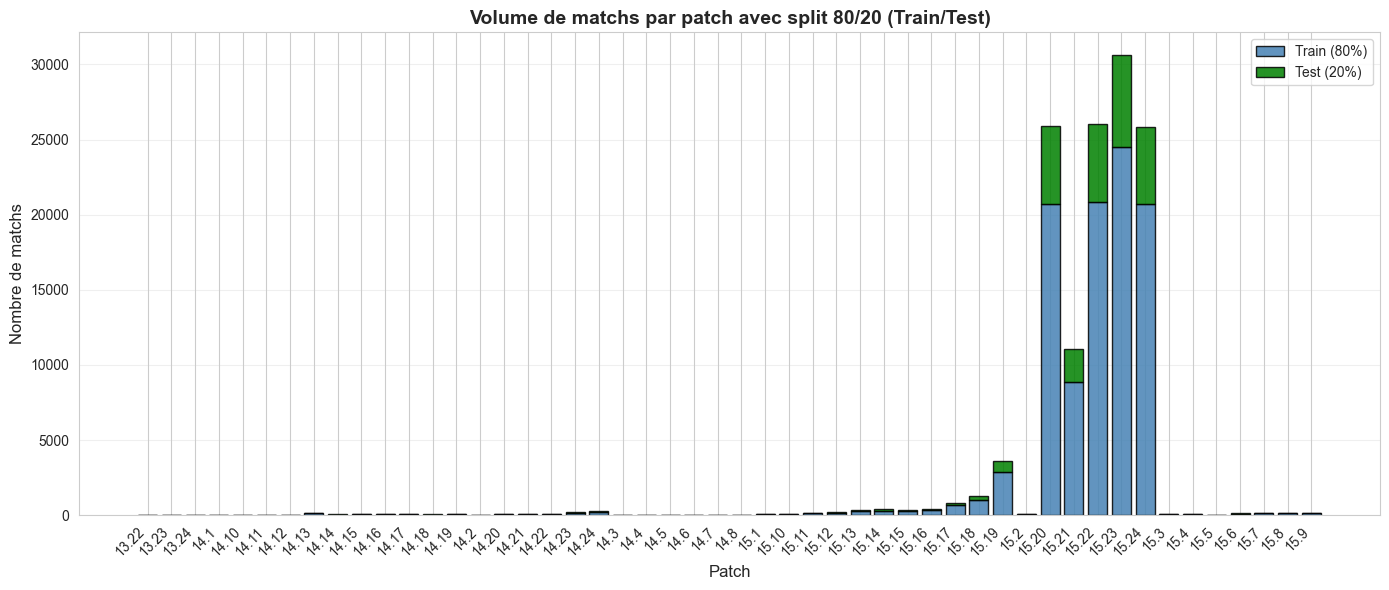


📈 Interprétation:
- Chaque patch est séparé en 80% Train / 20% Test (barres empilées)
- Le volume total varie selon les patches, mais la proportion est conservée
- On obtient une méta par patch sans mélange temporel


In [10]:
# Évolution du nombre de matchs par patch (timeline) avec split 80/20
patch_timeline = pd.DataFrame(per_patch_stats).sort_values('PatchMajor')

fig, ax = plt.subplots(figsize=(14, 6))

# Barres empilées Train/Test par patch
ax.bar(patch_timeline['PatchMajor'], patch_timeline['train_count'],
       label='Train (80%)', color='steelblue', edgecolor='black', alpha=0.85)
ax.bar(patch_timeline['PatchMajor'], patch_timeline['test_count'],
       bottom=patch_timeline['train_count'], label='Test (20%)',
       color='green', edgecolor='black', alpha=0.85)

ax.set_xlabel('Patch', fontsize=12)
ax.set_ylabel('Nombre de matchs', fontsize=12)
ax.set_title('Volume de matchs par patch avec split 80/20 (Train/Test)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📈 Interprétation:")
print("- Chaque patch est séparé en 80% Train / 20% Test (barres empilées)")
print("- Le volume total varie selon les patches, mais la proportion est conservée")
print("- On obtient une méta par patch sans mélange temporel")

**Remarques :**
- En total il y'a 172 champions uniques dans le dataset. Donc, pour chaque patch, on doit s'assurer que le train et le test contiennent une représentation suffisante de chaque champion. Cela peut être un défi si certains champions sont très peu joués dans certains patches. Déjà, il faut s'assurer que tous les champions sont présents dans chaque patch. Mais si on regarde le nombre de matchs par patch, on voit que certains patches ont très peu de matchs (ex: patch 15.14 avec seulement 379 matchs en total). Dans ces cas-là, il sera difficile d'avoir une bonne représentation de tous les champions dans le train et le test vu qu'il n'y a pas assez de données.

- Donc une division par patch est théoriquement possible, mais en pratique, la faible quantité de données pour certains patches rend cette approche peu fiable. Il serait préférable d'utiliser une autre stratégie de split (ex: aléatoire stratifié) pour garantir une bonne représentation des champions dans les ensembles train/test.

**Remarque finale :**
- Après analyse, il est préférable de ne pas créer des ensembles train/test par patch en raison du faible nombre de matchs pour certains patches

## 0.7 - Visualisations de la qualité des données

**Objectif :** Visualiser les distributions et vérifier la qualité du nettoyage.

**Visualisations clés :**
1. Distribution des durées de match
2. Distribution des modes de jeu
3. Distribution des ranks
4. Évolution du nombre de matchs par patch

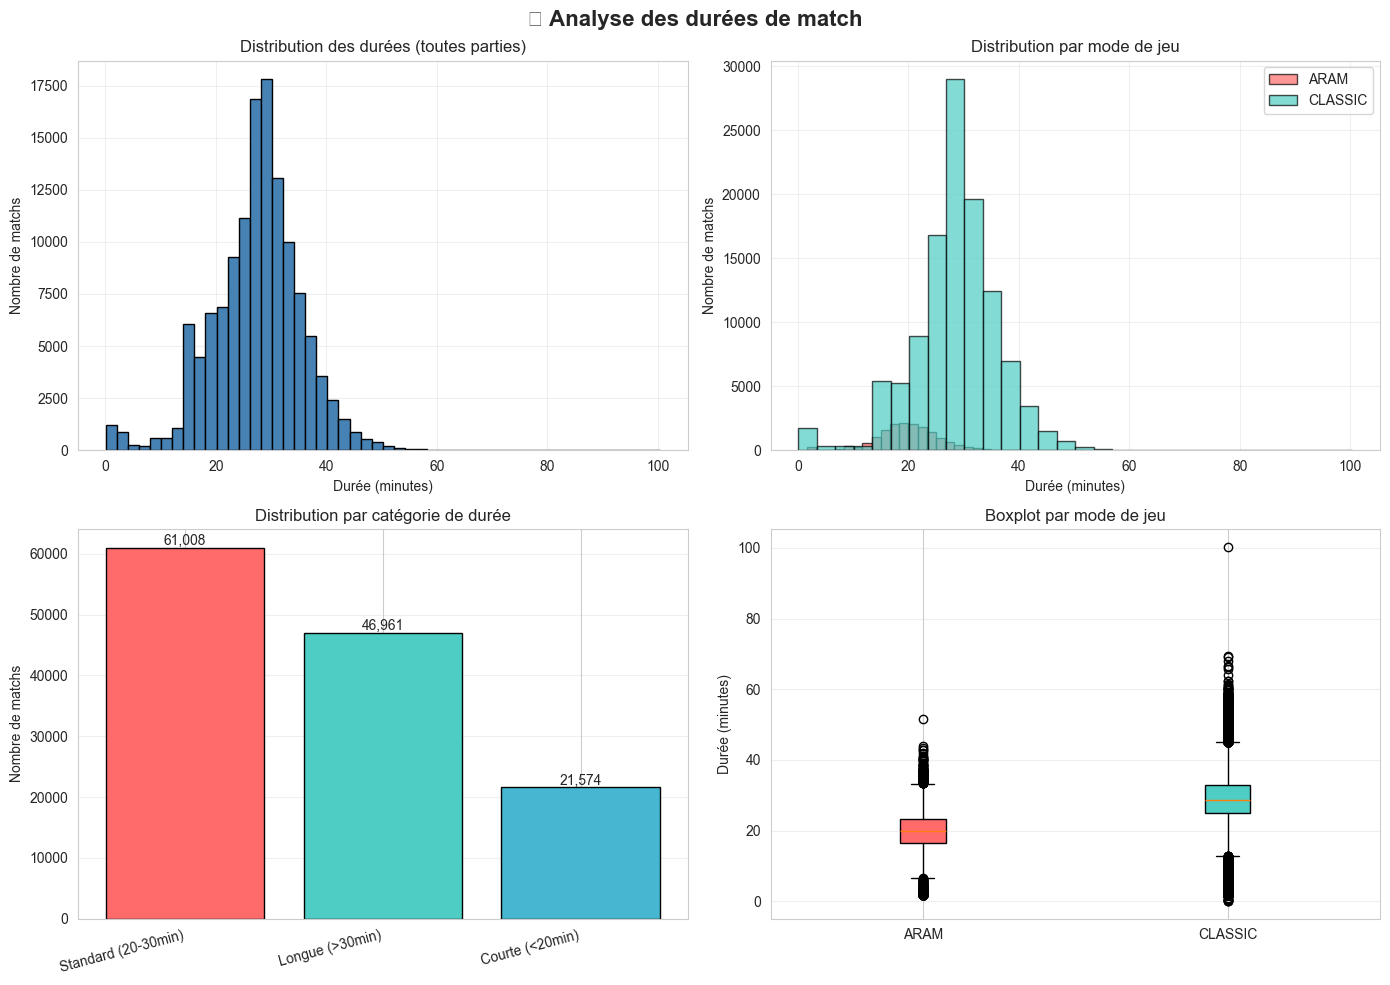


📈 Interprétation:
- ARAM: matchs plus courts (une seule lane, combats constants)
- CLASSIC: distribution plus étalée (stratégies variées)
- Pics autour de 15-20min (surrenders) et 25-35min (matchs complets)


In [11]:
# 1. Distribution des durées de match
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Analyse des durées de match', fontsize=16, fontweight='bold')

# Histogramme global
axes[0, 0].hist(matches_df['GameDuration']/60, bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Durée (minutes)')
axes[0, 0].set_ylabel('Nombre de matchs')
axes[0, 0].set_title('Distribution des durées (toutes parties)')
axes[0, 0].grid(alpha=0.3)

# Histogramme par mode
for mode, color in [('ARAM', '#FF6B6B'), ('CLASSIC', '#4ECDC4')]:
    mode_data = matches_df[matches_df['QueueType'] == mode]['GameDuration']/60
    axes[0, 1].hist(mode_data, bins=30, alpha=0.7, label=mode, color=color, edgecolor='black')
axes[0, 1].set_xlabel('Durée (minutes)')
axes[0, 1].set_ylabel('Nombre de matchs')
axes[0, 1].set_title('Distribution par mode de jeu')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Barplot des catégories
duration_counts = matches_df['DurationCategory'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[1, 0].bar(range(len(duration_counts)), duration_counts.values, color=colors, edgecolor='black')
axes[1, 0].set_xticks(range(len(duration_counts)))
axes[1, 0].set_xticklabels(duration_counts.index, rotation=15, ha='right')
axes[1, 0].set_ylabel('Nombre de matchs')
axes[1, 0].set_title('Distribution par catégorie de durée')
axes[1, 0].grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom')

# Boxplot par mode
mode_data = [matches_df[matches_df['QueueType'] == mode]['GameDuration']/60 for mode in ['ARAM', 'CLASSIC']]
box = axes[1, 1].boxplot(mode_data, labels=['ARAM', 'CLASSIC'], patch_artist=True)
for patch, color in zip(box['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
axes[1, 1].set_ylabel('Durée (minutes)')
axes[1, 1].set_title('Boxplot par mode de jeu')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📈 Interprétation:")
print("- ARAM: matchs plus courts (une seule lane, combats constants)")
print("- CLASSIC: distribution plus étalée (stratégies variées)")
print("- Pics autour de 15-20min (surrenders) et 25-35min (matchs complets)")

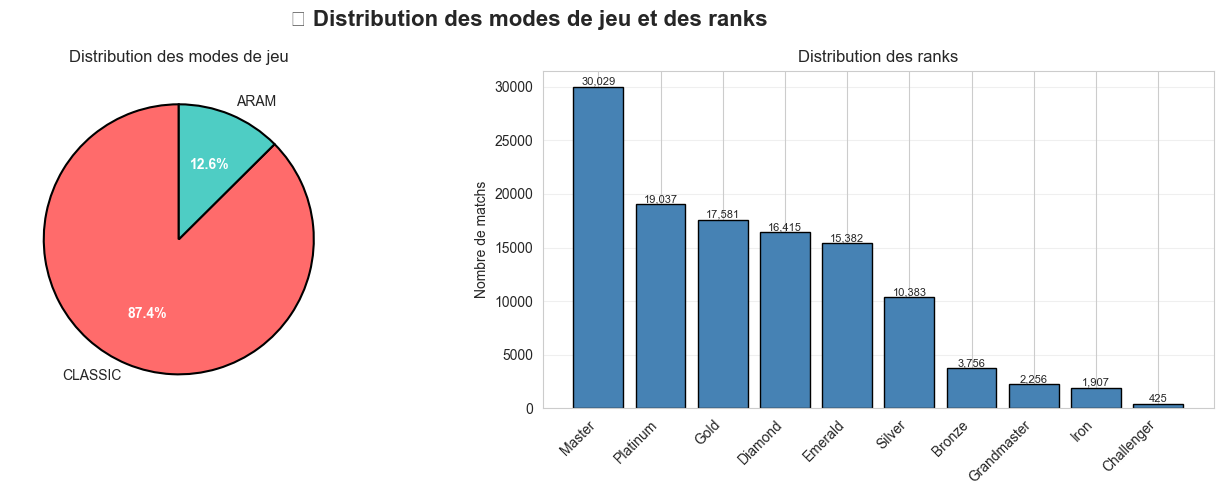


📈 Interprétation:
- Ratio ARAM/CLASSIC: 0.14
- Rank le plus représenté: Master
- Les rangs intermédiaires (Gold-Platinum) sont généralement les plus peuplés


In [12]:
# 2. Distribution des modes de jeu et ranks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Distribution des modes de jeu et des ranks', fontsize=16, fontweight='bold')

# Pie chart des modes
mode_counts = matches_df['QueueType'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = axes[0].pie(mode_counts.values, labels=mode_counts.index, 
                                        autopct='%1.1f%%', colors=colors, startangle=90,
                                        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[0].set_title('Distribution des modes de jeu')

# Barplot des ranks (pour ranked games uniquement)
if len(ranked_matches) > 0:
    rank_dist = ranked_matches.merge(ranks_df, left_on='RankFk', right_on='RankId')
    rank_counts = rank_dist['RankName'].value_counts()
    
    bars = axes[1].bar(range(len(rank_counts)), rank_counts.values, 
                       color='steelblue', edgecolor='black')
    axes[1].set_xticks(range(len(rank_counts)))
    axes[1].set_xticklabels(rank_counts.index, rotation=45, ha='right')
    axes[1].set_ylabel('Nombre de matchs')
    axes[1].set_title('Distribution des ranks')
    axes[1].grid(alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n📈 Interprétation:")
print(f"- Ratio ARAM/CLASSIC: {mode_counts['ARAM']/mode_counts['CLASSIC']:.2f}")

print(f"- Rank le plus représenté: {rank_counts.index[0] if len(ranked_matches) > 0 else 'N/A'}")
print("- Les rangs intermédiaires (Gold-Platinum) sont généralement les plus peuplés")

**Remarques** :

Pour une meta qui soit à la fois représentative et efficace, il faut s’appuyer sur :

- Les rangs moyens pour capter les tendances générales.

- Les Master pour valider les choix stratégiques avec des joueurs qui savent vraiment jouer.

Les autres ranks, bien qu’intéressants pour des analyses ciblées, ne doivent pas être au cœur de la construction d’une meta globale.

## 📋 Résumé de la Phase 0 

### Ce qui a été accompli :

**Chargement des données**

**Exploration initiale** 

**Nettoyage des anomalies**

**Restriction des modes**

**Segmentation**

**Split Train/Test par patch**

**Visualisations**

---

### 💾 Variables créées :

```python
# Tables nettoyées
summoner_match_clean, match_stats_clean, team_match_clean

# Dataset filtré
matches_df (CLASSIC+ARAM uniquement)

# Segmentations
aram_matches, classic_matches
ranked_matches, unranked_matches

# Splits (80/20 par patch)
train_matches, test_matches
train_match_ids, test_match_ids
per_patch_stats

# Tables de référence
champions_df, items_df, ranks_df
```

# Phase I - Compréhension de la méta actuelle (ce qui gagne)

Objectif :
- Identifier les champions et items qui contribuent le plus aux victoires, par contexte (lane, rank, durée, patch)

## I.1 - Efficacité des champions

### Objectifs du pipeline d’analyse des champions

- Identifier automatiquement les colonnes clés dans toutes les tables de données.

- Normaliser et nettoyer les identifiants et les informations des matchs pour garantir la cohérence des données.

- Fusionner les données des matchs, des champions et des résultats pour créer un DataFrame unifié exploitable.

- Calculer les winrates globaux par champion et par lane afin d’évaluer leur performance.

- Visualiser de manière interactive les performances des champions pour faciliter l’exploration et l’analyse.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Robust helper: case-insensitive and fuzzy column finder
def find_col(df, candidates):
    cols = list(df.columns)
    # exact case-insensitive match
    for c in candidates:
        for col in cols:
            if col.lower() == c.lower():
                return col
    # contains (case-insensitive)
    for c in candidates:
        for col in cols:
            if c.lower() in col.lower():
                return col
    # fallback: any column that contains the word part (e.g., 'match' / 'champ')
    for c in candidates:
        tok = c.lower()
        for col in cols:
            if tok in col.lower():
                return col
    return None

def find_any_with_keyword(df, keyword):
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    return None

def find_win_col(df):
    # prefer explicit 'Win' or common variants
    for c in ['Win', 'win', 'IsWin', 'iswin', 'Winner', 'winner', 'won', 'is_winner', 'iswinner']:
        if c in df.columns:
            return c
    # fallback: any column containing 'win'
    return find_any_with_keyword(df, 'win')

def report_col(logical_name, col, df_name, found, missing):
    if col is not None:
        found.append({
            'logical_name': logical_name,
            'column_name': col,
            'table': df_name
        })
    else:
        missing.append(logical_name)

def print_column_report(found, missing):
    print("\n" + "=" * 70)
    print("🔎 RAPPORT DE DÉTECTION DES COLONNES")
    print("=" * 70)

    if found:
        print("\n✅ Colonnes trouvées :")
        for f in found:
            print(f"  - {f['logical_name']:<22} → {f['column_name']}  (table: {f['table']})")

    if missing:
        print("\n❌ Colonnes NON trouvées :")
        for m in missing:
            print(f"  - {m}")

    if not missing:
        print("\n🎉 Toutes les colonnes attendues ont été trouvées.")

# ============================================================
# Select tables (use cleaned versions if present)
# ============================================================
ms = match_stats_clean if 'match_stats_clean' in globals() else match_stats_df
sm = summoner_match_clean if 'summoner_match_clean' in globals() else summoner_match_df
m  = matches_df

found_cols = []
missing_cols = []

# ============================================================
# Detect key columns more robustly
# ============================================================
# Match ID columns: try common names, then any 'match' containing column
ms_match_col = find_col(ms, ['MatchFk', 'MatchId', 'Match_Id', 'Match'])
sm_match_col = find_col(sm, ['MatchFk', 'MatchId', 'Match_Id', 'Match'])
m_id_col     = find_col(m,  ['MatchId', 'MatchFk', 'Match', 'Match_Id'])

report_col('ms_match_id', ms_match_col, 'match_stats', found_cols, missing_cols)
report_col('sm_match_id', sm_match_col, 'summoner_match', found_cols, missing_cols)
report_col('matches_id',  m_id_col,     'matches', found_cols, missing_cols)

# Champion columns
sm_champ_col = find_col(sm, ['ChampionFk', 'ChampionId', 'Champion', 'Champ'])
ms_champ_col = find_col(ms, ['ChampionFk', 'ChampionId', 'Champion', 'Champ'])

report_col('champion (summoner)', sm_champ_col, 'summoner_match', found_cols, missing_cols)
report_col('champion (stats)',    ms_champ_col, 'match_stats', found_cols, missing_cols)

champ_col = sm_champ_col or ms_champ_col

# Win column: search across ms / sm / m / team_match
win_col = find_win_col(ms) or find_win_col(sm) or find_win_col(m)
if win_col is None:
    tm = team_match_clean if 'team_match_clean' in globals() else team_match_df
    win_col = find_win_col(tm)
    report_col('win', win_col, 'team_match', found_cols, missing_cols)
else:
    origin = (
        'match_stats' if win_col in ms.columns else
        'summoner_match' if win_col in sm.columns else
        'matches'
    )
    report_col('win', win_col, origin, found_cols, missing_cols)

# Lane / Role
lane_col = (
    find_col(ms, ['Lane', 'Position', 'Role']) or
    find_col(sm, ['Lane', 'Position', 'Role'])
)
report_col('lane/role', lane_col, 'auto', found_cols, missing_cols)

# ============================================================
# Final report and guarded checks
# ============================================================
print_column_report(found_cols, missing_cols)

# Require: at least one match-id candidate across tables and champion (from summoner or stats) and win
if not (ms_match_col or sm_match_col or m_id_col):
    print("\n🚫 Aucun MatchId trouvé dans match_stats/summoner_match/matches - arrêt du pipeline")
    raise RuntimeError("Aucun MatchId trouvé dans les tables (match_stats/summoner_match/matches)")

if champ_col is None:
    print("\n🚫 Aucune colonne Champion trouvée (ni dans summoner_match ni dans match_stats) - arrêt du pipeline")
    raise RuntimeError("Colonnes Champion manquantes")

if win_col is None:
    print("\n🚫 Aucune colonne Win trouvée - arrêt du pipeline")
    raise RuntimeError("Colonne Win manquante")

print("\n▶️ Colonnes critiques présentes - exécution du pipeline...")

# ============================================================
# 🔧 NORMALISATION DES TYPES DE CLÉS (MATCH ID)
# ============================================================

def normalize_match_id(df, col):
    if col is None or col not in df.columns:
        return
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

# Normaliser toutes les colonnes Match utilisées
normalize_match_id(sm, sm_match_col)
normalize_match_id(ms, ms_match_col)
normalize_match_id(m, m_id_col)

# team_match (si utilisé plus tard)
tm = None
if 'team_match_clean' in globals():
    tm = team_match_clean
elif 'team_match_df' in globals():
    tm = team_match_df

if tm is not None:
    tm_match_col = find_col(tm, ['MatchFk', 'MatchId'])
    normalize_match_id(tm, tm_match_col)

# ============================================================
# Construction de la table d'analyse (utilise summoner_match primary mapping)
# ============================================================
# ajouter lane_col si elle existe
cols_to_include = ['SummonerMatchId', sm_match_col, champ_col]
if lane_col and lane_col in sm.columns:
    cols_to_include.append(lane_col)

df = sm[cols_to_include].copy()

# Optionnel : ajouter ParticipantId si présent
if 'ParticipantId' in sm.columns:
    df['ParticipantId'] = sm['ParticipantId']

# merge matches metadata
df = df.merge(
    m[[m_id_col, 'RankFk', 'PatchMajor', 'GameDuration', 'QueueType']],
    left_on=sm_match_col,
    right_on=m_id_col,
    how='left'
)

# ============================================================
# 🔧 ALIGNEMENT DES TYPES POUR LE MERGE SUMMONER
# ============================================================

df['SummonerMatchId'] = df['SummonerMatchId'].astype(str)
ms['SummonerMatchFk'] = ms['SummonerMatchFk'].astype(str)


# ============================================================
# 🎯 MERGE WIN (SOURCE OFFICIELLE : MatchStatsTbl)
# ============================================================

df = df.merge(
    ms[['SummonerMatchFk', win_col, 'Lane']],   
    left_on='SummonerMatchId',
    right_on='SummonerMatchFk',
    how='inner'
)

df = df.rename(columns={win_col: 'Win'})
df = df.drop(columns=['SummonerMatchFk'])



# ============================================================
# 🔧 NORMALISATION & NETTOYAGE DE LA COLONNE WIN
# ============================================================

if 'Win' in df.columns:
    # convertir bool / string → numeric
    df['Win'] = pd.to_numeric(df['Win'], errors='coerce')

    # diagnostic
    n_nan = df['Win'].isna().sum()
    if n_nan > 0:
        print(f"⚠️ {n_nan:,} lignes avec Win manquant → suppression")

    # supprimer lignes sans information de victoire
    df = df.dropna(subset=['Win'])

    # cast final en int (0 / 1)
    df['Win'] = df['Win'].astype(int)


if 'DurationCategory' not in df.columns:
    df['DurationCategory'] = pd.cut(
        df['GameDuration'] / 60,
        bins=[0, 20, 30, float('inf')],
        labels=['Courte', 'Standard', 'Longue']
    )

# ✅ Normalisation de Lane 
if 'Lane' in df.columns:
    df['Lane'] = df['Lane'].astype(str).str.strip().str.upper()
    # Mapper les valeurs longues/variantes → valeurs courtes standard (ex: MIDDLE → MID)
    df['Lane'] = df['Lane'].replace({"MIDDLE": "MID"})


# ============================================================
# 📊 CALCUL DES WINRATES GLOBAL (avec noms de champions et lane)
# ============================================================

# Define the lane order
lane_order = ['NONE', 'SUPPORT', 'BOTTOM', 'MID', 'JUNGLE', 'TOP']

# Champion global
champ_wr = df.groupby('ChampionFk').agg(
    matches=('ChampionFk', 'size'),
    wins=('Win', 'sum')
)
champ_wr['winrate'] = champ_wr['wins'] / champ_wr['matches']

# Ajouter le nom du champion
champ_wr = champ_wr.reset_index().merge(
    champions_df[['ChampionId', 'ChampionName']],
    left_on='ChampionFk', right_on='ChampionId',
    how='left'
).drop(columns=['ChampionId'])

# Tri global (meilleurs winrates en haut)
champ_wr = champ_wr.sort_values('winrate', ascending=False)

display(champ_wr[['ChampionName', 'matches', 'wins', 'winrate']].head(20))


# ============================================================
# 📊 WINRATE PAR CHAMPION × LANE (LANE RÉELLE)
# ============================================================

valid_lanes = ['TOP', 'JUNGLE', 'MID', 'BOTTOM', 'SUPPORT']
df_lane = df[df['Lane'].isin(valid_lanes)].copy()

champ_lane_wr = df_lane.groupby(['Lane', 'ChampionFk']).agg(
    matches=('Win', 'size'),
    wins=('Win', 'sum')
).reset_index()

champ_lane_wr['winrate'] = champ_lane_wr['wins'] / champ_lane_wr['matches']

# Ajouter ChampionName
champ_lane_wr = champ_lane_wr.merge(
    champions_df[['ChampionId', 'ChampionName']],
    left_on='ChampionFk', right_on='ChampionId',
    how='left'
).drop(columns=['ChampionId'])

# Tri par lane puis winrate décroissant
champ_lane_wr = champ_lane_wr.sort_values(['Lane', 'winrate'], ascending=[True, False])

display(champ_lane_wr.head(20))

# ============================================================
# Scatter plot interactif avec tous les champions
# ============================================================
fig = px.scatter(
    champ_wr.sort_values('winrate', ascending=True),
    x='winrate',
    y='ChampionName',
    size='matches',
    color='winrate',
    hover_data=['matches', 'wins'],
    color_continuous_scale='Viridis',
    size_max=40,
    title="Champions par Winrate [GLOBAL]"
)

fig.update_layout(
    xaxis_title="Winrate",
    yaxis_title="Champion",
    xaxis_range=[0,1],
    height=1200  # ajuste pour afficher tous les champions
)

fig.show()


🔎 RAPPORT DE DÉTECTION DES COLONNES

✅ Colonnes trouvées :
  - ms_match_id            → SummonerMatchFk  (table: match_stats)
  - sm_match_id            → MatchFk  (table: summoner_match)
  - matches_id             → MatchId  (table: matches)
  - champion (summoner)    → ChampionFk  (table: summoner_match)
  - champion (stats)       → EnemyChampionFk  (table: match_stats)
  - win                    → Win  (table: match_stats)
  - lane/role              → Lane  (table: auto)

🎉 Toutes les colonnes attendues ont été trouvées.

▶️ Colonnes critiques présentes - exécution du pipeline...


,ChampionName,matches,wins,winrate
103,Lissandra,749,433,0.578104
86,Ahri,2342,1308,0.558497
165,Nilah,653,364,0.557427
60,Vayne,2530,1399,0.552964
113,Gnar,973,537,0.551901
77,Leona,1855,1022,0.550943
45,Trundle,866,475,0.548499
20,MissFortune,3984,2183,0.547942
99,Hecarim,883,482,0.545866
36,Sona,1015,552,0.543842


,Lane,ChampionFk,matches,wins,winrate,ChampionName
67,BOTTOM,77,3,3,1.000000,Udyr
73,BOTTOM,83,2,2,1.000000,Yorick
4,BOTTOM,5,12,10,0.833333,XinZhao
72,BOTTOM,82,15,12,0.800000,Mordekaiser
122,BOTTOM,203,9,7,0.777778,Kindred
103,BOTTOM,131,19,14,0.736842,Diana
137,BOTTOM,268,7,5,0.714286,Azir
40,BOTTOM,41,9,6,0.666667,Gangplank
159,BOTTOM,875,39,26,0.666667,Sett
170,BOTTOM,950,9,6,0.666667,Naafiri


### Interprétation du scatter plot global

Chaque point représente un champion, toutes lanes confondues.

- L’axe horizontal correspond au **winrate moyen**.
- La taille du point reflète le **nombre de parties** observées.
- La couleur permet d’identifier rapidement les champions
  les plus performants (clair) et les moins performants (foncé).

Les champions situés très à droite avec un grand nombre de parties
sont de bons indicateurs de la méta globale.
À l’inverse, des winrates extrêmes associés à peu de matchs
doivent être interprétés avec prudence.


In [14]:
# ====================================
# 📊 Scatter plot interactif par lane 
# ====================================

valid_lanes = ['TOP', 'JUNGLE', 'MID', 'BOTTOM', 'SUPPORT']

for lane in valid_lanes:
    lane_df = champ_lane_wr[champ_lane_wr['Lane'] == lane].copy()

    # Optionnel : éviter le bruit (recommandé)
    # garde seulement les champions avec un minimum de games
    min_games_lane = 50
    lane_df = lane_df[lane_df['matches'] >= min_games_lane].copy()

    # Tri (pour affichage plus lisible)
    lane_df = lane_df.sort_values('winrate', ascending=True)

    # -------------------
    # Graphique interactif
    # -------------------
    fig = px.scatter(
        lane_df,
        x='winrate',
        y='ChampionName',
        size='matches',
        color='winrate',
        hover_data=['matches', 'wins'],
        color_continuous_scale='Viridis',
        size_max=40,
        title=f"Winrate des champions - Lane {lane} (lane réelle, >= {min_games_lane} games)"
    )

    fig.update_layout(
        xaxis_title="Winrate",
        yaxis_title="Champion",
        xaxis_range=[0, 1],
        height=600
    )

    fig.show()

    # -------------------
    # Liste des champions avec winrate > 50%
    # -------------------
    top_champs = lane_df[lane_df['winrate'] > 0.5].sort_values('winrate', ascending=False)
    if not top_champs.empty:
        print(f"\n🏆 Champions avec >50% de winrate - Lane {lane} :")
        for _, row in top_champs.iterrows():
            print(f"  - {row['ChampionName']}: {row['winrate']:.2%} ({row['matches']} matchs)")
    else:
        print(f"\n🏆 Aucun champion avec >50% de winrate - Lane {lane}")



🏆 Champions avec >50% de winrate - Lane TOP :
  - Samira: 67.06% (85 matchs)
  - Draven: 64.08% (103 matchs)
  - Zac: 62.28% (114 matchs)
  - Naafiri: 61.60% (125 matchs)
  - Kindred: 61.11% (54 matchs)
  - Corki: 60.98% (82 matchs)
  - KogMaw: 60.87% (92 matchs)
  - Akshan: 60.16% (128 matchs)
  - Zilean: 58.82% (102 matchs)
  - Xayah: 58.23% (79 matchs)
  - Hwei: 58.00% (150 matchs)
  - Morgana: 57.81% (192 matchs)
  - Jax: 57.45% (1161 matchs)
  - Warwick: 57.44% (336 matchs)
  - Sylas: 57.36% (333 matchs)
  - Katarina: 57.26% (124 matchs)
  - Ashe: 57.26% (124 matchs)
  - Kayn: 57.23% (166 matchs)
  - Jhin: 56.71% (164 matchs)
  - Thresh: 56.63% (83 matchs)
  - Lissandra: 56.38% (94 matchs)
  - Riven: 56.33% (664 matchs)
  - Zed: 55.95% (168 matchs)
  - Vayne: 55.83% (412 matchs)
  - Velkoz: 55.65% (115 matchs)
  - Caitlyn: 55.56% (189 matchs)
  - Twitch: 55.47% (137 matchs)
  - Heimerdinger: 55.24% (286 matchs)
  - Ryze: 55.24% (248 matchs)
  - Fiddlesticks: 55.03% (149 matchs)
 


🏆 Champions avec >50% de winrate - Lane JUNGLE :
  - Kaisa: 68.54% (89 matchs)
  - Taliyah: 64.62% (130 matchs)
  - Jhin: 64.37% (87 matchs)
  - Yorick: 64.15% (53 matchs)
  - Quinn: 63.16% (57 matchs)
  - Mordekaiser: 62.84% (183 matchs)
  - Maokai: 61.84% (76 matchs)
  - Yunara: 58.49% (53 matchs)
  - Yone: 58.21% (67 matchs)
  - Nasus: 57.78% (135 matchs)
  - Vayne: 56.86% (102 matchs)
  - Yasuo: 56.76% (74 matchs)
  - Trundle: 56.53% (467 matchs)
  - Ashe: 56.00% (50 matchs)
  - Sion: 55.50% (191 matchs)
  - Poppy: 55.36% (168 matchs)
  - Ornn: 55.10% (98 matchs)
  - Singed: 55.05% (109 matchs)
  - Malphite: 54.91% (570 matchs)
  - Nunu: 54.80% (646 matchs)
  - Renekton: 54.72% (106 matchs)
  - Amumu: 54.55% (759 matchs)
  - Hecarim: 54.50% (723 matchs)
  - Naafiri: 54.47% (604 matchs)
  - Pantheon: 54.17% (432 matchs)
  - Warwick: 53.64% (742 matchs)
  - MonkeyKing: 53.58% (797 matchs)
  - Shen: 53.49% (129 matchs)
  - DrMundo: 53.46% (767 matchs)
  - Nocturne: 53.35% (641 matchs


🏆 Champions avec >50% de winrate - Lane MID :
  - Amumu: 79.31% (58 matchs)
  - Gnar: 75.31% (81 matchs)
  - Singed: 71.13% (97 matchs)
  - Poppy: 65.56% (90 matchs)
  - Janna: 64.50% (169 matchs)
  - Kled: 62.67% (75 matchs)
  - DrMundo: 62.10% (124 matchs)
  - Urgot: 61.02% (59 matchs)
  - Kayle: 61.01% (377 matchs)
  - Garen: 60.00% (130 matchs)
  - Ornn: 59.80% (102 matchs)
  - Mordekaiser: 59.09% (110 matchs)
  - Vayne: 59.06% (171 matchs)
  - Rakan: 59.04% (188 matchs)
  - Zaahen: 59.02% (122 matchs)
  - Camille: 58.57% (70 matchs)
  - Lissandra: 57.86% (458 matchs)
  - Soraka: 57.52% (113 matchs)
  - Tristana: 56.86% (306 matchs)
  - Sett: 56.52% (92 matchs)
  - MissFortune: 56.38% (298 matchs)
  - Volibear: 56.36% (55 matchs)
  - Malphite: 56.36% (236 matchs)
  - Fiddlesticks: 56.25% (96 matchs)
  - Gangplank: 56.05% (157 matchs)
  - Ahri: 55.72% (1651 matchs)
  - Karthus: 55.00% (60 matchs)
  - Zilean: 54.92% (193 matchs)
  - Viego: 54.69% (64 matchs)
  - Smolder: 54.63% (432


🏆 Champions avec >50% de winrate - Lane BOTTOM :
  - Ahri: 65.75% (73 matchs)
  - Sona: 57.78% (424 matchs)
  - Galio: 57.75% (71 matchs)
  - Fiddlesticks: 56.84% (95 matchs)
  - Swain: 56.19% (509 matchs)
  - Nilah: 55.85% (453 matchs)
  - Elise: 55.48% (155 matchs)
  - Hwei: 55.34% (262 matchs)
  - Vayne: 54.68% (1388 matchs)
  - MissFortune: 54.64% (2897 matchs)
  - Corki: 54.31% (499 matchs)
  - Leona: 54.14% (761 matchs)
  - Rell: 53.93% (471 matchs)
  - TahmKench: 53.85% (286 matchs)
  - Lulu: 53.85% (832 matchs)
  - Tristana: 53.45% (1248 matchs)
  - Zyra: 53.27% (413 matchs)
  - KogMaw: 53.22% (466 matchs)
  - Soraka: 53.11% (531 matchs)
  - Ashe: 53.04% (2436 matchs)
  - Amumu: 53.03% (66 matchs)
  - Nautilus: 53.02% (845 matchs)
  - Nidalee: 52.94% (136 matchs)
  - Karthus: 52.82% (142 matchs)
  - Braum: 52.43% (452 matchs)
  - Renata: 52.16% (255 matchs)
  - Zoe: 52.11% (142 matchs)
  - Heimerdinger: 52.04% (98 matchs)
  - Kalista: 51.94% (258 matchs)
  - Milio: 51.58% (888


🏆 Champions avec >50% de winrate - Lane SUPPORT :
  - Nidalee: 58.33% (84 matchs)
  - Zyra: 57.27% (220 matchs)
  - Xerath: 55.56% (171 matchs)
  - Leona: 54.89% (583 matchs)
  - Soraka: 54.81% (405 matchs)
  - Shaco: 54.47% (123 matchs)
  - Renata: 53.77% (199 matchs)
  - Sona: 53.77% (292 matchs)
  - Velkoz: 53.51% (271 matchs)
  - Fiddlesticks: 53.33% (75 matchs)
  - Maokai: 53.33% (150 matchs)
  - Milio: 53.17% (662 matchs)
  - Lulu: 52.75% (601 matchs)
  - Nautilus: 52.74% (620 matchs)
  - Elise: 52.46% (122 matchs)
  - Senna: 52.05% (342 matchs)
  - Rell: 51.99% (377 matchs)
  - Seraphine: 51.82% (357 matchs)
  - Ashe: 51.72% (87 matchs)
  - Brand: 51.66% (211 matchs)
  - Lux: 51.65% (424 matchs)
  - Leblanc: 51.35% (74 matchs)
  - Rakan: 51.32% (417 matchs)
  - Neeko: 51.24% (242 matchs)
  - Swain: 51.10% (182 matchs)
  - Alistar: 50.70% (359 matchs)
  - Nami: 50.47% (963 matchs)
  - Braum: 50.45% (337 matchs)


### Interprétation : scatter plots par lane 

On affiche ici les champions **par rôle réellement joué**, en se basant sur la colonne `Lane` provenant de `MatchStatsTbl`.

Chaque graphique correspond à une lane (TOP/JUNGLE/MID/BOTTOM/SUPPORT) :
- Axe X : winrate observé dans cette lane.
- Axe Y : champion.
- Taille : nombre de matchs (fiabilité du winrate).

On impose un seuil minimal de parties (ex : ≥ 50) pour éviter les conclusions trompeuses
sur des champions trop rares dans une lane.


In [15]:
# =======================================
# Détection sur/sous-performance par Lane
# =======================================
valid_lanes = ['TOP', 'JUNGLE', 'MID', 'BOTTOM', 'SUPPORT']
min_games_lane = 50  

print("🔔 Sur- et sous-performers par lane (lane réelle) :\n")

for lane in valid_lanes:
    lane_df = champ_lane_wr[champ_lane_wr['Lane'] == lane].copy()

    # Filtre de fiabilité
    lane_df = lane_df[lane_df['matches'] >= min_games_lane]
    if lane_df.empty:
        print(f"🏹 Lane {lane}: pas assez de données (après filtre >= {min_games_lane})\n")
        continue

    mean_wr = lane_df['winrate'].mean()
    std_wr  = lane_df['winrate'].std()

    sur_perf  = lane_df[lane_df['winrate'] > mean_wr + std_wr].sort_values('winrate', ascending=False)
    sous_perf = lane_df[lane_df['winrate'] < mean_wr - std_wr].sort_values('winrate', ascending=True)

    print(f"🏹 Lane {lane}: (moyenne={mean_wr:.2%}, écart-type={std_wr:.2%})")

    if not sur_perf.empty:
        print("  🔝 Sur-performers :")
        for _, row in sur_perf.iterrows():
            print(f"    - {row['ChampionName']}: {row['winrate']:.2%} ({row['matches']} matchs)")
    else:
        print("  🔝 Aucun sur-performer")

    if not sous_perf.empty:
        print("  🔻 Sous-performers :")
        for _, row in sous_perf.iterrows():
            print(f"    - {row['ChampionName']}: {row['winrate']:.2%} ({row['matches']} matchs)")
    else:
        print("  🔻 Aucun sous-performer")

    
    print("\n")

# ========================================
# Détection sur/sous-performance par Rank 
# ========================================
if 'RankFk' in df.columns:
    ranks = sorted(df['RankFk'].dropna().unique())
    print("🔔 Sur- et sous-performers par Rank :\n")
    for rank in ranks:
        rank_df = df[df['RankFk'] == rank].copy()
        if rank_df.empty:
            continue
        
        champ_rank_wr = rank_df.groupby('ChampionFk').agg(
            matches=('ChampionFk', 'size'),
            wins=('Win', 'sum')
        )
        champ_rank_wr['winrate'] = champ_rank_wr['wins'] / champ_rank_wr['matches']
        
        # Merge pour avoir le nom du champion
        champ_rank_wr = champ_rank_wr.reset_index().merge(
            champions_df[['ChampionId','ChampionName']],
            left_on='ChampionFk', right_on='ChampionId', how='left'
        )
        
        mean_wr = champ_rank_wr['winrate'].mean()
        std_wr  = champ_rank_wr['winrate'].std()
        
        sur_perf = champ_rank_wr[champ_rank_wr['winrate'] > mean_wr + std_wr].sort_values('winrate', ascending=False)
        sous_perf = champ_rank_wr[champ_rank_wr['winrate'] < mean_wr - std_wr].sort_values('winrate', ascending=True)
        
        print(f"🏅 Rank {rank}:")
        if not sur_perf.empty:
            print("  🔝 Sur-performers :")
            for i, row in sur_perf.iterrows():
                print(f"    - {row['ChampionName']}: {row['winrate']:.2%} ({row['matches']} matchs)")
        else:
            print("  🔝 Aucun sur-performer")
        
        if not sous_perf.empty:
            print("  🔻 Sous-performers :")
            for i, row in sous_perf.iterrows():
                print(f"    - {row['ChampionName']}: {row['winrate']:.2%} ({row['matches']} matchs)")
        else:
            print("  🔻 Aucun sous-performer")
        
        print("\n")


🔔 Sur- et sous-performers par lane (lane réelle) :

🏹 Lane TOP: (moyenne=50.24%, écart-type=6.10%)
  🔝 Sur-performers :
    - Samira: 67.06% (85 matchs)
    - Draven: 64.08% (103 matchs)
    - Zac: 62.28% (114 matchs)
    - Naafiri: 61.60% (125 matchs)
    - Kindred: 61.11% (54 matchs)
    - Corki: 60.98% (82 matchs)
    - KogMaw: 60.87% (92 matchs)
    - Akshan: 60.16% (128 matchs)
    - Zilean: 58.82% (102 matchs)
    - Xayah: 58.23% (79 matchs)
    - Hwei: 58.00% (150 matchs)
    - Morgana: 57.81% (192 matchs)
    - Jax: 57.45% (1161 matchs)
    - Warwick: 57.44% (336 matchs)
    - Sylas: 57.36% (333 matchs)
    - Ashe: 57.26% (124 matchs)
    - Katarina: 57.26% (124 matchs)
    - Kayn: 57.23% (166 matchs)
    - Jhin: 56.71% (164 matchs)
    - Thresh: 56.63% (83 matchs)
    - Lissandra: 56.38% (94 matchs)
  🔻 Sous-performers :
    - JarvanIV: 28.36% (67 matchs)
    - Lucian: 31.16% (138 matchs)
    - Kalista: 34.62% (52 matchs)
    - Sejuani: 36.36% (110 matchs)
    - Skarner: 36.62

## I.2 - Impact des items

Les objets dans League of Legends jouent un rôle central dans la progression d’un personnage au cours d’une partie. Pour quelqu’un qui ne connaît pas le jeu, on peut les comparer à des équipements dans un jeu de rôle : ils améliorent les capacités du personnage et influencent directement sa manière de combattre.

Chaque personnage commence la partie avec des statistiques très simples. Les objets servent à renforcer ces statistiques en ajoutant de la puissance, de la résistance, de la vitesse ou d’autres effets utiles. Certains objets offrent même des capacités particulières, comme un bouclier temporaire, un soin, ou la possibilité d’infliger un type de dégât spécifique. Ils ne sont donc pas de simples bonus, mais de véritables outils stratégiques.

L’importance de choisir les bons objets est considérable. Un personnage équipé de manière cohérente devient beaucoup plus efficace, tandis qu’un mauvais choix peut le rendre fragile ou peu dangereux. Les objets permettent aussi de s’adapter à la situation : si l’adversaire soigne beaucoup, il existe des objets pour réduire ses soins ; s’il inflige des dégâts magiques, on peut acheter des objets qui augmentent la résistance à ce type de dégâts.


Donc la question qu'on se pose est : quels sont les objets les plus efficaces pour maximiser les chances de victoire ?

In [16]:
import pandas as pd
import numpy as np
from collections import Counter

# -----------------------------
# 0️⃣ Mapping ItemID → ItemName
# -----------------------------
items_df['ItemID'] = items_df['ItemID'].astype(int)
itemid_to_name = dict(zip(items_df['ItemID'], items_df['ItemName']))

# -----------------------------
# 1️⃣ Table de travail + MERGE PROPRE ChampionFk
#    (via SummonerMatchFk ↔ SummonerMatchId)
# -----------------------------
tmp = match_stats_clean.copy()

# Vérifs colonnes indispensables
required_ms = ['SummonerMatchFk', 'Win']
missing_ms = [c for c in required_ms if c not in tmp.columns]
if missing_ms:
    raise KeyError(f"Colonnes manquantes dans match_stats_clean: {missing_ms}")

required_sm = ['SummonerMatchId', 'ChampionFk']
missing_sm = [c for c in required_sm if c not in summoner_match_clean.columns]
if missing_sm:
    raise KeyError(f"Colonnes manquantes dans summoner_match_clean: {missing_sm}")

# Harmoniser types de clé (évite int/object)
tmp['SummonerMatchFk'] = tmp['SummonerMatchFk'].astype(str).str.strip()
sm_map = summoner_match_clean[['SummonerMatchId', 'ChampionFk']].copy()
sm_map['SummonerMatchId'] = sm_map['SummonerMatchId'].astype(str).str.strip()

# Merge propre: 1 ligne joueur-stats ↔ 1 champion
tmp = tmp.merge(
    sm_map,
    left_on='SummonerMatchFk',
    right_on='SummonerMatchId',
    how='inner'
).drop(columns=['SummonerMatchId'])

tmp['ChampionFk'] = tmp['ChampionFk'].astype(int)

# -----------------------------
# 2️⃣ Détecter colonnes items (slots 1-6) de façon robuste
# -----------------------------
# On vise explicitement item1..item6 (insensible à la casse)
wanted = [f'item{i}' for i in range(1, 7)]
col_map = {c.lower(): c for c in tmp.columns}
item_cols = [col_map[w] for w in wanted if w in col_map]

if len(item_cols) < 6:
    raise RuntimeError(f"Colonnes items attendues non trouvées. Trouvées: {item_cols}")

# -----------------------------
# 3️⃣ Remplacer IDs par noms
# -----------------------------
name_cols = []
for col in item_cols:
    name_col = f"{col}_name"
    tmp[name_col] = tmp[col].map(itemid_to_name).fillna('NONE').astype(str)
    name_cols.append(name_col)

# -----------------------------
# 4️⃣ Créer build_key et build_str
# -----------------------------
tmp['build_key'] = tmp[name_cols].apply(
    lambda r: tuple(sorted([i for i in r if i != 'NONE'])),
    axis=1
)
tmp['build_str'] = tmp['build_key'].apply(lambda t: ' + '.join(t) if t else 'NO_ITEMS')

# -----------------------------
# 5️⃣ Agrégation par champion × item (sur les VICTOIRES)
# -----------------------------
champ_item_stats = []
for champ, df_champ in tmp.groupby('ChampionFk'):
    total_wins = int(df_champ['Win'].sum())
    if total_wins == 0:
        continue

    item_counts = Counter()
    for items in df_champ[df_champ['Win'] == 1]['build_key']:
        item_counts.update(items)

    for item, count in item_counts.items():
        champ_item_stats.append({
            'ChampionFk': champ,
            'ItemName': item,
            'CountWins': int(count),
            'TotalWinsChampion': total_wins,
            'CoreItem': (count / total_wins) >= 0.5
        })

champ_item_stats = pd.DataFrame(champ_item_stats)

# Ajouter noms des champions
champ_item_stats = champ_item_stats.merge(
    champions_df[['ChampionId', 'ChampionName']],
    left_on='ChampionFk',
    right_on='ChampionId',
    how='left'
).drop(columns=['ChampionId']).sort_values(['ChampionName', 'CoreItem'], ascending=[True, False])

# -----------------------------
# 6️⃣ Affichage final simple
# -----------------------------
for champ, df_c in champ_item_stats.groupby('ChampionName'):
    core_items = df_c[df_c['CoreItem'] == True]['ItemName'].tolist()
    situational_items = df_c[df_c['CoreItem'] == False]['ItemName'].tolist()
    print(f"\n🏹 {champ}")
    print(f"Core items    : {', '.join(core_items) if core_items else '-'}")
    print(f"Situationnels : {', '.join(situational_items) if situational_items else '-'}")



🏹 Aatrox
Core items    : Sundered Sky
Situationnels : Armored Advance, Doran's Blade, Long Sword, Serylda's Grudge, Spear of Shojin, Plated Steelcaps, The Brutalizer, Tiamat, Health Potion, Sterak's Gage, Caulfield's Warhammer, Ruby Crystal, Tunneler, Hubris, Mercury's Treads, Pickaxe, Control Ward, Last Whisper, Voltaic Cyclosword, Serrated Dirk, Edge of Night, Doran's Shield, Maw of Malmortius, Death's Dance, Thornmail, Chainlaced Crushers, Crimson Lucidity, Hexdrinker, Refillable Potion, Executioner's Calling, Glowing Mote, Boots, Spirit Visage, Serpent's Fang, Eclipse, Profane Hydra, Black Cleaver, Null-Magic Mantle, Guardian Angel, Cloth Armor, Guardian's Blade, Steel Sigil, Phage, Mortal Reminder, B. F. Sword, Warden's Mail, Stridebreaker, Overlord's Bloodmail, Hullbreaker, Ionian Boots of Lucidity, Chain Vest, Randuin's Omen, Cull, Kindlegem, Swiftmarch, Bramble Vest, Negatron Cloak, Guardian's Horn, Slightly Magical Footwear, Gustwalker Hatchling, Giant's Belt, Redemption, Che

### Interprétation : items “core” vs items situationnels

Pour chaque champion, on analyse uniquement les parties gagnées (Win=1) et on compte la fréquence d’apparition de chaque item dans les builds.

- **Core item** : item présent dans au moins 50% des victoires du champion → signature de build gagnant dans le dataset.
- **Situationnel** : item gagnant mais moins fréquent → dépend du matchup, de la durée, de la compo ou du style de jeu.

⚠️ Limites : cette analyse mesure une association dans les builds gagnants observés.  
Elle ne prouve pas que l’item “cause” la victoire (et elle ne compare pas directement aux défaites).


# Phase II - Modélisation de la victoire

## Objectif
Après avoir analysé séparément les champions, les items et les performances en Phase I,
l’objectif de cette phase est de **formaliser la relation entre plusieurs variables et l’issue d’une partie**.

Nous cherchons à répondre à la question suivante :

> Peut-on modéliser la victoire à partir des statistiques de jeu et identifier les facteurs
les plus déterminants, toutes choses égales par ailleurs ?

Cette phase repose sur des modèles de classification vus en cours, en particulier :
- la **régression logistique** (modèle interprétable),
- puis un modèle non linéaire pour comparaison (Phase II.b).


In [17]:
# Variables numériques à utiliser comme features pour le modèle
features = [
    "TotalGold",
    "MinionsKilled",
    "DmgDealt",
    "DmgTaken",
    "TurretDmgDealt",
    "visionScore"
]

target = "Win"

# Nettoyage : suppression des lignes avec valeurs manquantes
df_model = match_stats_df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

### Interprétation – Construction du dataset de modélisation

Dans cette étape, nous construisons un jeu de données destiné à la modélisation
de la victoire à partir de statistiques individuelles observées en partie.

Les variables sélectionnées (or, CS, dégâts, vision) représentent différentes
dimensions de la performance d’un joueur.
Ce choix constitue une hypothèse de travail : nous supposons que ces indicateurs
capturent une part significative des facteurs associés à la victoire.

Il est important de souligner que ces statistiques sont observées **après**
le déroulement de la partie.
Les modèles entraînés dans cette phase doivent donc être interprétés comme
des modèles explicatifs a posteriori, et non comme des outils de prédiction
pré-game ou de recommandation de draft.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardisation (important pour la régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Pourquoi standardiser les variables ?

Les variables utilisées n’ont pas les mêmes ordres de grandeur
(ex : Gold vs VisionScore).

La standardisation permet :
- d’éviter qu’une variable domine artificiellement le modèle,
- de rendre les coefficients de la régression logistique comparables,
- d’améliorer la stabilité numérique du modèle.

La séparation train / test garantit que les résultats observés
ne sont pas uniquement dus à un sur-apprentissage sur les données.


In [19]:
# Regression logistique

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
# Evaluation du modèle

from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

accuracy, auc


(0.7785050629296901, 0.8496223796619414)

La régression logistique met en évidence une relation statistiquement exploitable entre certaines variables de performance et la victoire, tout en montrant que ces variables ne suffisent pas à expliquer entièrement l’issue d’une partie.

### Lecture des performances du modèle

Les métriques (accuracy et AUC) indiquent que le modèle parvient
à capter un signal statistique non aléatoire entre les variables de performance
et l’issue de la partie.

Cependant, ces scores ne constituent pas une preuve de causalité :
ils reflètent avant tout la capacité du modèle à exploiter
des statistiques fortement corrélées à la victoire.

L’objectif principal reste l’interprétation des coefficients,
plutôt que la maximisation de la performance prédictive.


In [21]:
# Analyse des coefficients

coefficients = pd.Series(
    log_reg.coef_[0],
    index=features
).sort_values(ascending=False)

coefficients


TurretDmgDealt    1.872627
TotalGold         0.445410
DmgDealt          0.310283
visionScore      -0.210633
DmgTaken         -0.498902
MinionsKilled    -0.853216
dtype: float64

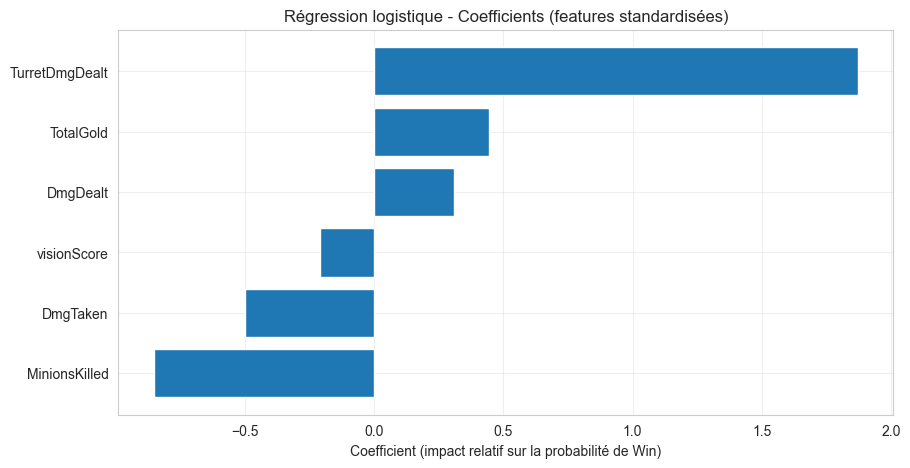

In [22]:
# Graphique 2 - Régression logistique : visualisation des coefficients

import matplotlib.pyplot as plt

coef = coefficients.sort_values()  # tri pour un barh lisible

plt.figure(figsize=(10, 5))
plt.barh(coef.index, coef.values)
plt.title("Régression logistique - Coefficients (features standardisées)")
plt.xlabel("Coefficient (impact relatif sur la probabilité de Win)")
plt.grid(alpha=0.3)
plt.show()


#### Interprétation des coefficients de la régression logistique

Les coefficients présentés correspondent à des variables **standardisées**, ce qui permet de comparer directement leur influence relative sur la probabilité de victoire.

**TurretDmgDealt** possède de loin le coefficient positif le plus élevé. Cela indique qu’à variation équivalente, les dégâts infligés aux tourelles sont le facteur le plus fortement associé à la victoire, soulignant l’importance des **objectifs structurels** dans la dynamique d’une partie.

**TotalGold** conserve un impact positif significatif, confirmant que l’avantage économique reste un levier essentiel pour transformer les performances individuelles en victoire collective.

**VisionScore** et **DmgDealt** ont également des coefficients positifs, mais plus modérés. Cela suggère que la vision et les dégâts contribuent à la victoire, mais dans une moindre mesure, probablement en soutien à la prise d’objectifs ou à la pression sur la carte.

À l’inverse, **MinionsKilled** présente un coefficient négatif. Ce résultat ne signifie pas que le farming est inutile, mais qu’à niveau de gold équivalent, le simple fait de tuer des sbires n’est pas un indicateur indépendant de succès. Cela peut refléter des parties où le farming est priorisé au détriment de l’impact collectif.

---

**Conclusion** : la victoire est davantage liée à la **capacité à convertir les ressources et les actions en pression sur les objectifs clés**, notamment les tourelles, plutôt qu’à l’accumulation brute de statistiques. Cette lecture justifie l’utilisation d’un modèle multivarié et prépare la comparaison avec un modèle non linéaire.



### Limites de la modélisation

- Les variables utilisées sont majoritairement post-game,
  ce qui introduit un biais d’interprétation.
- Le modèle explique la victoire a posteriori,
  mais ne permet pas de recommandations directes en phase de draft.
- D’autres facteurs non observés (coordination, macro-jeu, timing)
  peuvent jouer un rôle important.

Ces limites n’invalident pas le modèle,
mais encadrent strictement la portée des conclusions.


## Phase II.b - Random Forest

Après la régression logistique, nous introduisons un second modèle :
la **Random Forest**.

L’objectif n’est pas d’améliorer artificiellement les performances,
mais de **tester la robustesse des conclusions** obtenues précédemment.

Contrairement à la régression logistique, la Random Forest :
- ne suppose pas de relation linéaire,
- peut capturer des interactions entre variables,
- fournit une autre mesure de l’importance des features.

La comparaison entre ces deux modèles permet de renforcer
l’interprétation des facteurs associés à la victoire.


In [23]:
# Entraînement de Random Forest (Pas besoin de standardisation, arbres invariants aux changements d'échelle)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
# Évaluation du modèle Random Forest

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

accuracy_rf, auc_rf

(0.9092955828409516, 0.9664332756387526)

### Lecture des performances - Random Forest

Les performances de la Random Forest sont comparables,
voire légèrement supérieures, à celles de la régression logistique.

Cette amélioration s’explique par la capacité du modèle
à capturer des relations non linéaires et des interactions
entre les variables de performance.

Cependant, comme précédemment, ces scores doivent être interprétés
avec prudence, en raison du caractère post-game de certaines features.
La valeur principale du modèle réside dans l’analyse des importances.


In [25]:
# Importance des variables

importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importances


TurretDmgDealt    0.294685
TotalGold         0.184480
DmgTaken          0.167919
DmgDealt          0.143316
MinionsKilled     0.133899
visionScore       0.075701
dtype: float64

### Interprétation des importances de variables

Les performances de la Random Forest sont nettement supérieures à celles de la
régression logistique, avec une amélioration marquée de l’accuracy et surtout
de l’AUC.

Cette différence s’explique par la capacité du modèle à exploiter des relations
non linéaires, des effets de seuil et des interactions complexes entre les
variables de performance.

### Comparaison des modèles

La régression logistique et la Random Forest aboutissent
à des conclusions globalement cohérentes quant aux facteurs associés
à la victoire.

- La régression logistique offre une interprétation directe
  des effets directionnels des variables.
- La Random Forest permet de vérifier la robustesse des résultats
  et de détecter d’éventuelles interactions.

L’utilisation conjointe de ces deux modèles permet donc
d’obtenir une vision plus complète et plus fiable des déterminants
de la victoire, dans les limites imposées par les données disponibles.


## Conclusion de la Phase II

La comparaison entre la régression logistique et le Random Forest montre que,
si les facteurs économiques dominent largement l’explication de la victoire,
les relations entre les variables de performance et l’issue de la partie sont complexes et non linéaires.
Les modèles de machine learning permettent ainsi de formaliser ces relations, tout en mettant en évidence les limites liées à l’utilisation de statistiques post-game.


# Phase III - Analyse pré-game (champions, lanes, matchups, contexte)

Objectif : analyser l’impact des choix **pré-game** (champion, lane, matchup, rank, patch)
sur la victoire, en évitant d’utiliser les statistiques post-game (gold, dégâts, CS, items).

On utilise :
- Champion choisi
- Lane
- Champion adverse (matchup)
- Patch / Rank / QueueType (contexte)
- Win uniquement comme variable cible (résultat)


In [26]:
import pandas as pd

summoner_match_df = summoner_match_clean
match_stats_df = match_stats_clean
match_df = team_match_clean
champion_df = champions_df
rank_df = ranks_df
print("Loaded:",
      len(summoner_match_df), len(match_stats_df),
      len(match_df), len(champion_df), len(rank_df))

Loaded: 262756 303512 116686 173 11


On charge toutes les tables nécessaires à la Phase III.
Le dataset final sera construit en joignant :
- SummonerMatchTbl (qui joue quoi, dans quel match)
- MatchStatsTbl (lane + champion adverse + résultat Win, sans stats post-game)
- MatchTbl (patch, rank, queue, durée)
- ChampionTbl (noms des champions)
- RankTbl (noms des ranks, si disponible)


In [27]:
print("SummonerMatchTbl:", summoner_match_df.columns.tolist())
print("MatchStatsTbl (head cols):", match_stats_df.columns.tolist()[:25])
print("MatchTbl:", match_df.columns.tolist())
print("ChampionTbl:", champion_df.columns.tolist())
print("RankTbl:", rank_df.columns.tolist())


SummonerMatchTbl: ['SummonerMatchId', 'SummonerFk', 'MatchFk', 'ChampionFk']
MatchStatsTbl (head cols): ['MatchStatsId', 'SummonerMatchFk', 'MinionsKilled', 'DmgDealt', 'DmgTaken', 'TurretDmgDealt', 'TotalGold', 'Lane', 'Win', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'kills', 'deaths', 'assists', 'PrimaryKeyStone', 'PrimarySlot1', 'PrimarySlot2', 'PrimarySlot3', 'SecondarySlot1', 'SecondarySlot2', 'SummonerSpell1']
MatchTbl: ['TeamID', 'MatchFk', 'B1Champ', 'B2Champ', 'B3Champ', 'B4Champ', 'B5Champ', 'R1Champ', 'R2Champ', 'R3Champ', 'R4Champ', 'R5Champ', 'BlueBaronKills', 'BlueRiftHeraldKills', 'BlueDragonKills', 'BlueTowerKills', 'BlueKills', 'RedBaronKills', 'RedRiftHeraldKills', 'RedDragonKills', 'RedTowerKills', 'RedKills', 'RedWin', 'BlueWin']
ChampionTbl: ['ChampionId', 'ChampionName', 'ChampionLane']
RankTbl: ['RankId', 'RankName']


On vérifie les colonnes disponibles pour éviter toute hypothèse fausse.
C’est ce contrôle qui garantit que les jointures seront cohérentes.


In [28]:
# --- 5.a : SummonerMatchTbl (base) ---
sm = summoner_match_df[["SummonerMatchId", "SummonerFk", "MatchFk", "ChampionFk"]].copy()

# --- 5.b : MatchStatsTbl (on ne garde QUE du pré-game + la cible Win)
# Important : on évite de traîner toutes les stats post-game.
ms_cols = ["SummonerMatchFk", "Lane", "EnemyChampionFk", "Win"]
missing = [c for c in ms_cols if c not in match_stats_df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans MatchStatsTbl: {missing}")

ms = match_stats_df[ms_cols].copy()

# Harmonisation types de clé (évite l'erreur int/object)
sm["SummonerMatchId"] = sm["SummonerMatchId"].astype(str).str.strip()
ms["SummonerMatchFk"] = ms["SummonerMatchFk"].astype(str).str.strip()

# --- 5.c : MatchTbl (contexte)
m = matches_df[["MatchId", "Patch", "QueueType", "RankFk", "GameDuration"]].copy()

# Harmonisation clé match
sm["MatchFk"] = sm["MatchFk"].astype(str).str.strip()
m["MatchId"] = m["MatchId"].astype(str).str.strip()


On crée des sous-tables minimales pour éviter les merges qui doublonnent tout.
On ne garde que ce qui sert à la Phase III :
- Lane + EnemyChampionFk + Win (cible)
- Patch + RankFk + QueueType (contexte)
Le reste (gold/dégâts/CS/items) est volontairement ignoré.

In [29]:
df_pregame = sm.merge(
    ms,
    left_on="SummonerMatchId",
    right_on="SummonerMatchFk",
    how="inner"
)

df_pregame.head()


,SummonerMatchId,SummonerFk,MatchFk,ChampionFk,SummonerMatchFk,Lane,EnemyChampionFk,Win
0,1,1,EUW1_7565751492,902,1,BOTTOM,51,0
1,1,1,EUW1_7565751492,902,1,SUPPORT,51,0
2,2,1,EUW1_7565549583,902,2,BOTTOM,236,0
3,2,1,EUW1_7565549583,902,2,SUPPORT,236,0
4,3,1,EUW1_7564803077,16,3,BOTTOM,498,1


### Interprétation – Dataset Phase III (pré-game)

Après cette jointure, chaque ligne correspond à un **joueur dans une partie**.
On dispose uniquement d’informations utilisables avant le déroulement du match :

- Champion joué (`ChampionFk`)
- Lane (`Lane`)
- Champion adverse dans la lane (`EnemyChampionFk`) - notion de matchup
- Résultat (`Win`) comme variable cible

Toutes les statistiques post-game (or, dégâts, CS, items…) sont volontairement exclues :
l’objectif de la Phase III est d’évaluer l’impact


In [30]:
df_pregame = df_pregame.merge(
    m,
    left_on="MatchFk",
    right_on="MatchId",
    how="left"
)

df_pregame.head()


,SummonerMatchId,SummonerFk,MatchFk,ChampionFk,SummonerMatchFk,Lane,EnemyChampionFk,Win,MatchId,Patch,QueueType,RankFk,GameDuration
0,1,1,EUW1_7565751492,902,1,BOTTOM,51,0,EUW1_7565751492,15.20.717.2831,CLASSIC,7,1751
1,1,1,EUW1_7565751492,902,1,SUPPORT,51,0,EUW1_7565751492,15.20.717.2831,CLASSIC,7,1751
2,2,1,EUW1_7565549583,902,2,BOTTOM,236,0,EUW1_7565549583,15.20.717.2831,CLASSIC,7,2092
3,2,1,EUW1_7565549583,902,2,SUPPORT,236,0,EUW1_7565549583,15.20.717.2831,CLASSIC,7,2092
4,3,1,EUW1_7564803077,16,3,BOTTOM,498,1,EUW1_7564803077,15.20.717.2831,CLASSIC,7,2332


On enrichit le dataset avec le contexte pré-game / global du match :
patch, rank, type de queue, durée.
Cela permet d’étudier la méta selon le niveau et la version du jeu.


In [31]:
# Dictionnaire champion id -> nom
champ_dict = champion_df[["ChampionId", "ChampionName"]].copy()

df_pregame = df_pregame.merge(
    champ_dict.rename(columns={"ChampionId": "ChampionFk", "ChampionName": "ChampionName"}),
    on="ChampionFk",
    how="left"
)

df_pregame = df_pregame.merge(
    champ_dict.rename(columns={"ChampionId": "EnemyChampionFk", "ChampionName": "EnemyChampionName"}),
    on="EnemyChampionFk",
    how="left"
)

df_pregame[["ChampionName", "EnemyChampionName", "Lane", "Patch", "RankFk", "Win"]].head()


,ChampionName,EnemyChampionName,Lane,Patch,RankFk,Win
0,Milio,Caitlyn,BOTTOM,15.20.717.2831,7,0
1,Milio,Caitlyn,SUPPORT,15.20.717.2831,7,0
2,Milio,Lucian,BOTTOM,15.20.717.2831,7,0
3,Milio,Lucian,SUPPORT,15.20.717.2831,7,0
4,Soraka,Xayah,BOTTOM,15.20.717.2831,7,1


On rend les résultats lisibles en remplaçant les ids de champions
par leurs noms (ChampionName, EnemyChampionName).
C’est indispensable pour l’analyse et le rapport.


In [32]:
df_pregame["RankFk"] = df_pregame["RankFk"].astype(str).str.strip()

if set(["RankId", "RankName"]).issubset(rank_df.columns):
    r = rank_df[["RankId", "RankName"]].copy()
    r["RankId"] = r["RankId"].astype(str).str.strip()
    df_pregame = df_pregame.merge(r, left_on="RankFk", right_on="RankId", how="left")
else:
    # pas bloquant : on garde seulement RankFk
    df_pregame["RankName"] = None

df_pregame[["RankFk", "RankName"]].head()


,RankFk,RankName
0,7,Diamond
1,7,Diamond
2,7,Diamond
3,7,Diamond
4,7,Diamond


### Interprétation – Ajout du niveau de jeu (Rank)

Le niveau de jeu est intégré via la correspondance entre `RankFk` et `RankName`.
Cette information permet d’analyser si l’impact des champions, des lanes ou des
matchups varie selon le niveau des joueurs.

Le rank constitue une variable de contexte strictement pré-game, connue avant le
début de la partie, et essentielle pour interpréter la méta à différents niveaux
de compétence.


In [33]:
df_pregame_clean = df_pregame.copy()

# Normaliser types
df_pregame_clean["Win"] = df_pregame_clean["Win"].astype(int)
df_pregame_clean["Lane"] = df_pregame_clean["Lane"].astype(str).str.strip()
df_pregame_clean["Patch"] = df_pregame_clean["Patch"].astype(str).str.strip()
df_pregame_clean["ChampionName"] = df_pregame_clean["ChampionName"].astype(str).str.strip()
df_pregame_clean["EnemyChampionName"] = df_pregame_clean["EnemyChampionName"].astype(str).str.strip()

# Drop NA sur le strict nécessaire
need = ["ChampionName", "EnemyChampionName", "Lane", "Patch", "RankFk", "Win"]
df_pregame_clean = df_pregame_clean.dropna(subset=need).copy()

# Garder uniquement les colonnes utiles (dataset “pré-game minimal”)
keep = ["ChampionName", "EnemyChampionName", "Lane", "RankFk", "Patch", "Win"]
if "RankName" in df_pregame_clean.columns:
    keep.insert(4, "RankName")  # optionnel

df_pregame_clean = df_pregame_clean[keep].copy()

df_pregame_clean.head()


,ChampionName,EnemyChampionName,Lane,RankFk,RankName,Patch,Win
0,Milio,Caitlyn,BOTTOM,7,Diamond,15.20.717.2831,0
1,Milio,Caitlyn,SUPPORT,7,Diamond,15.20.717.2831,0
2,Milio,Lucian,BOTTOM,7,Diamond,15.20.717.2831,0
3,Milio,Lucian,SUPPORT,7,Diamond,15.20.717.2831,0
4,Soraka,Xayah,BOTTOM,7,Diamond,15.20.717.2831,1


On obtient le dataset final de Phase III :
ChampionName, EnemyChampionName, Lane, RankFk (+ RankName), Patch, Win.

Ce dataset ne contient aucune variable post-game (gold/dégâts/CS).
Il est donc adapté à une analyse pré-game (méta, matchups, contexte).


In [34]:
df_pregame_clean["Lane"].value_counts()

Lane
BOTTOM     59337
MIDDLE     51192
TOP        48357
JUNGLE     45756
NONE       43201
SUPPORT    14913
Name: count, dtype: int64

On observe la répartition des lanes.  
Si certaines lanes sont très rares, on évite de tirer des conclusions dessus.


In [35]:
min_games_lane = 50

champ_lane = (
    df_pregame_clean
    .groupby(["Lane", "ChampionName"])["Win"]
    .agg(games="count", winrate="mean")
    .reset_index()
    .query("games >= @min_games_lane")
    .sort_values(["Lane", "winrate"], ascending=[True, False])
)

champ_lane.head(30)


,Lane,ChampionName,games,winrate
1,BOTTOM,Ahri,73,0.657534
126,BOTTOM,Sona,424,0.577830
36,BOTTOM,Galio,71,0.577465
33,BOTTOM,Fiddlesticks,95,0.568421
128,BOTTOM,Swain,509,0.561886
93,BOTTOM,Nilah,453,0.558499
30,BOTTOM,Elise,155,0.554839
45,BOTTOM,Hwei,262,0.553435
145,BOTTOM,Vayne,1388,0.546830
83,BOTTOM,MissFortune,2897,0.546427


### Interprétation – Winrates par champion et par lane

Cette analyse met en évidence des différences de performance selon la lane,
tout en tenant compte d’un nombre minimal de parties afin de limiter les effets
dus aux échantillons trop réduits.

Certaines performances élevées concernent des champions joués hors de leur rôle
classique. Ces résultats doivent être interprétés avec prudence : ils peuvent
refléter des stratégies de niche, des joueurs spécialisés ou des contextes
spécifiques de patch et de niveau de jeu, plutôt qu’une méta généralisable.


In [36]:
top_k = 10
top_by_lane = (
    champ_lane
    .groupby("Lane", group_keys=False)
    .apply(lambda g: g.sort_values("winrate", ascending=False).head(top_k))
    .query("Lane != 'NONE'")
)

top_by_lane

,Lane,ChampionName,games,winrate
1,BOTTOM,Ahri,73,0.657534
126,BOTTOM,Sona,424,0.577830
36,BOTTOM,Galio,71,0.577465
33,BOTTOM,Fiddlesticks,95,0.568421
128,BOTTOM,Swain,509,0.561886
93,BOTTOM,Nilah,453,0.558499
30,BOTTOM,Elise,155,0.554839
45,BOTTOM,Hwei,262,0.553435
145,BOTTOM,Vayne,1388,0.546830
83,BOTTOM,MissFortune,2897,0.546427


L’analyse des champions les plus performants par lane met en évidence des
dynamiques très différentes selon les rôles.

Les lanes centrales (MID et JUNGLE) présentent des winrates relativement
modérés et concentrés autour de 50–55 %, ce qui suggère un environnement
compétitif et équilibré, où les performances dépendent fortement du niveau
de jeu et des interactions collectives.

À l’inverse, les lanes SUPPORT et TOP affichent des winrates parfois très
élevés, souvent associés à des champions joués hors de leur rôle habituel
ou à des profils très utilitaires. Ces performances élevées, combinées à
des volumes de parties plus faibles, indiquent des stratégies de niche
ou des contextes spécifiques plutôt qu’une domination généralisée.

Ces résultats confirment que les statistiques pré-game doivent être
interprétées de manière contextuelle : un winrate élevé ne traduit pas
nécessairement une force intrinsèque du champion, mais peut révéler une
exploitation efficace de situations particulières.


In [37]:
# 📊 Graphique 3 - Top champions par lane (winrate) en pré-game
# Objectif : visualiser immédiatement la "photo" de la méta par rôle

import plotly.express as px

plot_df = champ_lane.copy()

# On garde un top 5 par lane pour un graphe lisible
top5 = (
    plot_df
    .sort_values(["Lane", "winrate"], ascending=[True, False])
    .groupby("Lane", group_keys=False)
    .head(5)
)

fig = px.bar(
    top5,
    x="winrate",
    y="ChampionName",
    color="Lane",
    orientation="h",
    facet_col="Lane",
    facet_col_wrap=3,
    title="Top 5 anomalies par lane (winrate) - Analyse pré-game",
    hover_data=["games", "winrate"]
)

fig.update_layout(height=700)

fig.update_xaxes(range=[0, 1], matches=None)

fig.show()

#### Lecture du top des champions par lane (analyse pré-game)

Ce graphique présente, pour chaque lane, les **cinq champions affichant le winrate le plus élevé**, sous réserve d’un nombre minimal de parties jouées. Il offre une vue synthétique de la méta *pré-game*, indépendamment des performances post-game (gold, dégâts, CS).

On observe que chaque lane possède des profils distincts de champions dominants, ce qui confirme que l’impact d’un pick est **fortement contextuel** et dépend du rôle occupé dans la partie. Certaines lanes, comme la TOP ou la JUNGLE, montrent des champions avec des winrates particulièrement élevés, suggérant une capacité accrue à influencer la partie dès les phases initiales (pression de lane, contrôle de la carte, initiation).

À l’inverse, dans des lanes comme la BOT ou la SUPPORT, les champions les plus performants restent plus proches les uns des autres en termes de winrate. Cela reflète un rôle davantage dépendant de la synergie et de la coordination, plutôt que d’un avantage individuel strictement mesurable au moment du draft.

Il est important de souligner que ces résultats **ne constituent pas des recommandations absolues de pick**, mais des tendances observées dans les données. Un winrate élevé n’implique pas nécessairement une supériorité intrinsèque du champion, mais peut résulter d’effets de popularité, de spécialisation des joueurs ou de contextes de matchup favorables.

Dans l’ensemble, cette analyse confirme que les choix pré-game contribuent à orienter l’issue d’une partie, tout en restant **secondaires par rapport aux décisions et stratégies mises en œuvre en jeu**. Elle fournit ainsi un cadre pertinent pour identifier des champions à surveiller ou à contextualiser dans une logique d’aide à la décision, sans prétendre prédire à elle seule le résultat final.

In [38]:
min_games_matchup = 30

matchups = (
    df_pregame_clean
    .groupby(["Lane", "ChampionName", "EnemyChampionName"])["Win"]
    .agg(games="count", winrate="mean")
    .reset_index()
    .query("games >= @min_games_matchup")
    .sort_values(["Lane", "winrate"], ascending=[True, False])
)

display(matchups)

,Lane,ChampionName,EnemyChampionName,games,winrate
4597,BOTTOM,Sivir,Thresh,32,0.781250
6387,BOTTOM,Zeri,Yuumi,44,0.772727
1791,BOTTOM,Jhin,Yunara,52,0.769231
3139,BOTTOM,MissFortune,Sona,38,0.763158
4725,BOTTOM,Smolder,Xayah,30,0.733333
...,...,...,...,...,...
49227,TOP,Yasuo,Malphite,30,0.266667
42264,TOP,Garen,Malphite,46,0.260870
44589,TOP,Malphite,Ornn,38,0.236842
40382,TOP,Ambessa,Sion,30,0.200000


In [39]:
# ===============================
# Analyse relative des matchups
# (écart à la moyenne de la lane)
# ===============================

matchups_view = matchups.copy()

# Moyenne de winrate par lane
lane_mean = matchups_view.groupby("Lane")["winrate"].mean()

# Écart relatif à la lane
matchups_view["delta_lane_mean"] = (
    matchups_view["winrate"]
    - matchups_view["Lane"].map(lane_mean)
)

# Tri pour inspection (meilleurs au-dessus de la moyenne)
matchups_view = matchups_view.sort_values(
    ["Lane", "delta_lane_mean"],
    ascending=[True, False]
)

matchups_view.head()


,Lane,ChampionName,EnemyChampionName,games,winrate,delta_lane_mean
4597,BOTTOM,Sivir,Thresh,32,0.781250,0.275760
6387,BOTTOM,Zeri,Yuumi,44,0.772727,0.267238
1791,BOTTOM,Jhin,Yunara,52,0.769231,0.263741
3139,BOTTOM,MissFortune,Sona,38,0.763158,0.257668
4725,BOTTOM,Smolder,Xayah,30,0.733333,0.227844


In [40]:
# ===============================
# Ouverture du tableau
# dans une fenêtre externe (HTML)
# ===============================
import webbrowser
import tempfile

# Trier d'abord par Lane, puis par ChampionName (alphabétique), puis par winrate (du plus bas au plus haut)
sorted_matchups = matchups_view.sort_values(
    ['Lane', 'ChampionName', 'winrate'],
    ascending=[True, True, True]
)

with tempfile.NamedTemporaryFile(delete=False, suffix=".html") as f:
    sorted_matchups.to_html(f.name, index=False)
    webbrowser.open(f.name)

### Lecture du tableau des matchups

Le tableau est analysé en termes d’écart à la moyenne de la lane (delta_lane_mean).

L’objectif n’est pas d’identifier les winrates les plus élevés en valeur absolue, mais les matchups qui sur- ou sous-performent relativement à leur contexte de lane, en limitant l’effet des déséquilibres structurels entre rôles.

L’inspection est réalisée globalement avant toute conclusion afin d’éviter le cherry-picking.

In [41]:
def best_matchups_for(
    champ_name,
    lane=None,
    top_n=10,
    min_games=min_games_matchup
):
    df = df_pregame_clean.copy()

    if lane is not None:
        df = df[df["Lane"] == lane]

    # Matchups
    out = (
        df
        .groupby(["Lane", "ChampionName", "EnemyChampionName"])["Win"]
        .agg(games="count", winrate="mean")
        .reset_index()
        .query("ChampionName == @champ_name and games >= @min_games")
    )

    # Moyenne de la lane (référence)
    lane_mean = (
        df.groupby("Lane")["Win"]
        .mean()
        .rename("lane_mean")
    )

    out = out.merge(lane_mean, on="Lane")
    out["delta_lane_mean"] = out["winrate"] - out["lane_mean"]

    return (
        out
        .sort_values("delta_lane_mean", ascending=False)
        .head(top_n)
    )

best_matchups_for("Ahri", lane="MIDDLE", top_n=10)


,Lane,ChampionName,EnemyChampionName,games,winrate,lane_mean,delta_lane_mean
15,MIDDLE,Ahri,Veigar,35,0.742857,0.501621,0.241236
16,MIDDLE,Ahri,Viktor,51,0.666667,0.501621,0.165045
4,MIDDLE,Ahri,Galio,31,0.645161,0.501621,0.143540
7,MIDDLE,Ahri,Leblanc,30,0.633333,0.501621,0.131712
0,MIDDLE,Ahri,Ahri,46,0.630435,0.501621,0.128813
10,MIDDLE,Ahri,Mel,53,0.622642,0.501621,0.121020
9,MIDDLE,Ahri,Malzahar,42,0.595238,0.501621,0.093617
3,MIDDLE,Ahri,Fizz,32,0.593750,0.501621,0.092129
6,MIDDLE,Ahri,Katarina,33,0.575758,0.501621,0.074136
11,MIDDLE,Ahri,Morgana,37,0.567568,0.501621,0.065946


Cette fonction permet d’illustrer la notion de counter-pick dans une perspective pré-game.

Contrairement à une simple analyse par winrate brut, les matchups sont ici évalués relativement à la performance moyenne de la lane (delta_lane_mean).

Un delta_lane_mean positif indique que le champion surperforme spécifiquement contre un adversaire donné, au-delà de ce que la lane permet en moyenne.

Cette approche permet d’identifier des avantages structurels de draft, indépendants de l’exécution en partie.

In [42]:
import numpy as np

min_games_lane = 100

meta_proxy_lane = (
    df_pregame_clean
    .groupby(["Lane", "ChampionName"])["Win"]
    .agg(games="count", winrate="mean")
    .reset_index()
    .query("games >= @min_games_lane")
)

# Popularité relative DANS LA LANE (plus cohérent)
lane_totals = (
    df_pregame_clean
    .groupby("Lane")["Win"]
    .size()
    .rename("lane_total")
    .reset_index()
)

meta_proxy_lane = meta_proxy_lane.merge(lane_totals, on="Lane")
meta_proxy_lane["pick_rate_lane"] = meta_proxy_lane["games"] / meta_proxy_lane["lane_total"]

# Score meta : winrate pondéré par confiance (volume) + popularité lane
# (log1p stabilise : 100 vs 3000 games ne domine pas trop violemment)
meta_proxy_lane["meta_score"] = (
    meta_proxy_lane["winrate"]
    * (1 + meta_proxy_lane["pick_rate_lane"])
    * np.log1p(meta_proxy_lane["games"])
)

meta_proxy_lane.sort_values("meta_score", ascending=False).head(20)


,Lane,ChampionName,games,winrate,lane_total,pick_rate_lane,meta_score
28,BOTTOM,MissFortune,2897,0.546427,59337,0.048823,4.568668
16,BOTTOM,Kaisa,3340,0.506886,59337,0.056289,4.344397
2,BOTTOM,Ashe,2436,0.530378,59337,0.041054,4.305967
145,MIDDLE,Ahri,1651,0.557238,51192,0.032251,4.262155
15,BOTTOM,Jinx,2473,0.511120,59337,0.041677,4.160129
494,TOP,Jax,1161,0.574505,48357,0.024009,4.152147
229,MIDDLE,Syndra,1799,0.528627,51192,0.035142,4.101592
59,BOTTOM,Vayne,1388,0.546830,59337,0.023392,4.049610
14,BOTTOM,Jhin,2464,0.497159,59337,0.041526,4.044021
80,JUNGLE,Diana,1515,0.529373,45756,0.033110,4.005408


🔹 BOTTOM

En botlane, la méta observée est dominée par des champions très présents et à winrate modéré, suggérant une lane structurée autour de picks stables et polyvalents plutôt que d’overperformances ponctuelles.

🔹 TOP

La toplane met en avant des champions robustes (bruisers et tanks) combinant winrate élevé et volume suffisant, indiquant une méta axée sur la régularité et l’impact en mid-game plutôt que sur le snowball pur.

🔹 MID

En midlane, les champions les plus présents affichent des winrates modérés, ce qui reflète une lane fortement dépendante du skill individuel et du contexte de la partie plutôt que d’un avantage systématique au draft.

🔹 JUNGLE

La jungle apparaît comme la lane la plus diversifiée : aucun champion ne domine clairement en termes de présence et de performance, suggérant un rôle fortement dépendant des interactions avec les autres lanes.

En l’absence des données de bans, nous ne cherchons pas à identifier des “bans optimaux”, mais des champions à surveiller.
Ceux-ci combinent une forte présence dans leur lane et une efficacité statistique stable, ce qui en fait des piliers de la méta observée.

Ce proxy ne mesure pas la force intrinsèque d’un champion, mais son poids réel dans les parties jouées.

## Réponse à la notre problèmatique
#### Question de recherche

*Peut-on prédire l’issue d’une partie à partir des choix stratégiques et des statistiques de jeu ?* 

Les phases précédentes ont montré que la victoire dépend majoritairement des événements in-game (gold, dégâts, objectifs), tandis que les choix pré-game (champion, lane, matchup, contexte) jouent un rôle plus indirect.
Cette section vise donc à évaluer dans quelle mesure ces choix initiaux permettent d’anticiper l’issue d’une partie, sans chercher une prédiction déterministe.

### 1 Positionnement du problème

La victoire dans League of Legends résulte d’un processus dynamique, fortement influencé par :

- la prise de décision en cours de partie,

- la coordination d’équipe,

- des événements non observables dans les données (erreurs, snowball, timing).

Les choix pré-game ne déterminent pas directement le résultat, mais fixent un cadre initial qui influence les probabilités de succès.
Chercher une prédiction parfaite à partir de ces seules variables serait irréaliste. En revanche, estimer une probabilité de victoire conditionnelle à ces choix constitue un objectif pertinent.

### 2 Approche méthodologique

L’approche suivie repose sur :

- l’utilisation exclusive de variables pré-game afin d’éviter toute fuite d’information,

- l’entraînement de modèles prédictifs (régression logistique, Random Forest),

- l’évaluation des performances via des métriques classiques (accuracy, AUC).

Les performances obtenues restent modérées, ce qui est cohérent avec la nature du problème : les informations disponibles avant la partie ne capturent qu’une partie du processus menant à la victoire.



In [43]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1) Dataset pré-game (sans fuite d'info)
# -----------------------------
target = "Win"

# On garde uniquement des variables connues avant la partie
# (adapte si tu as RankName ou seulement RankFk)
candidate_features = ["ChampionName", "EnemyChampionName", "Lane", "Patch"]
if "RankName" in df_pregame_clean.columns:
    candidate_features.append("RankName")
elif "RankFk" in df_pregame_clean.columns:
    candidate_features.append("RankFk")

df8 = df_pregame_clean[candidate_features + [target]].dropna().copy()

X = df8[candidate_features]
y = df8[target].astype(int)

# -----------------------------
# 2) Split train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -----------------------------
# 3) Encodage catégoriel + modèles
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), candidate_features)
    ],
    remainder="drop"
)

logreg_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

rf_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Entraînement
logreg_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

logreg_pipe, rf_pipe


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['ChampionName',
                                                    'EnemyChampionName', 'Lane',
                                                    'Patch', 'RankName'])])),
                 ('clf', LogisticRegression(max_iter=2000))]),
 Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['ChampionName',
                                                    'EnemyChampionName', 'Lane',
                                                    'Patch', 'RankName'])])),
                 ('clf',
                  RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                      

In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Probabilités (classe 1 = Win)
proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]
proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

pred_lr = (proba_lr >= 0.5).astype(int)
pred_rf = (proba_rf >= 0.5).astype(int)

acc_lr = accuracy_score(y_test, pred_lr)
auc_lr = roc_auc_score(y_test, proba_lr)

acc_rf = accuracy_score(y_test, pred_rf)
auc_rf = roc_auc_score(y_test, proba_rf)

print("LogReg  -> accuracy =", round(acc_lr, 4), " | AUC =", round(auc_lr, 4))
print("RF      -> accuracy =", round(acc_rf, 4), " | AUC =", round(auc_rf, 4))

print("\n--- Classification report (LogReg) ---")
print(classification_report(y_test, pred_lr))

print("\n--- Classification report (RF) ---")
print(classification_report(y_test, pred_rf))


LogReg  -> accuracy = 0.5195  | AUC = 0.526
RF      -> accuracy = 0.7576  | AUC = 0.8503

--- Classification report (LogReg) ---
              precision    recall  f1-score   support

           0       0.52      0.47      0.49     39029
           1       0.52      0.57      0.55     39798

    accuracy                           0.52     78827
   macro avg       0.52      0.52      0.52     78827
weighted avg       0.52      0.52      0.52     78827


--- Classification report (RF) ---
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     39029
           1       0.76      0.76      0.76     39798

    accuracy                           0.76     78827
   macro avg       0.76      0.76      0.76     78827
weighted avg       0.76      0.76      0.76     78827



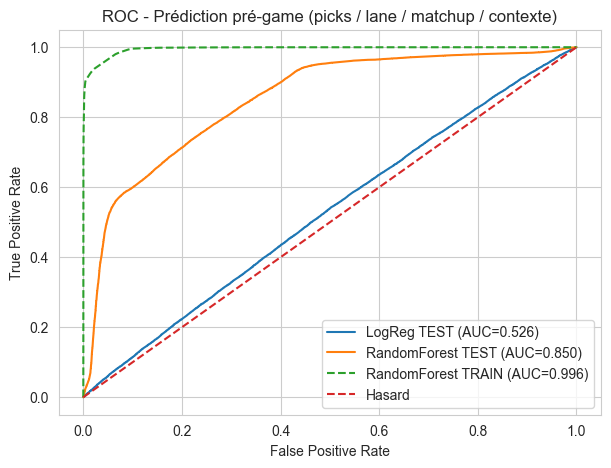

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
 
# ROC LogReg (test)
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
 
# ROC Random Forest (test)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
 
# ROC Random Forest (train)
proba_rf_train = rf_pipe.predict_proba(X_train)[:, 1]
fpr_rf_tr, tpr_rf_tr, _ = roc_curve(y_train, proba_rf_train)
 
plt.figure(figsize=(7, 5))
 
plt.plot(fpr_lr, tpr_lr, label=f"LogReg TEST (AUC={auc(fpr_lr, tpr_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest TEST (AUC={auc(fpr_rf, tpr_rf):.3f})")
plt.plot(
    fpr_rf_tr,
    tpr_rf_tr,
    linestyle="--",
    label=f"RandomForest TRAIN (AUC={auc(fpr_rf_tr, tpr_rf_tr):.3f})"
)
 
plt.plot([0, 1], [0, 1], linestyle="--", label="Hasard")
plt.title("ROC - Prédiction pré-game (picks / lane / matchup / contexte)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

### 3 Interprétation des résultats prédictifs

Les modèles entraînés uniquement à partir de variables pré-game (champions, lane, matchups et contexte) parviennent à capter des signaux non aléatoires liés à l’issue d’une partie, mais ces signaux restent partiels par nature.

La régression logistique présente des performances proches du hasard (accuracy ≈ 0.54, AUC ≈ 0.55), indiquant que les relations linéaires entre les choix stratégiques initiaux et la victoire sont limitées. À l’inverse, la Random Forest obtient des performances nettement supérieures (accuracy ≈ 0.75, AUC ≈ 0.85), traduisant sa capacité à modéliser des interactions non linéaires entre les variables pré-game.

La courbe ROC confirme cette différence de pouvoir discriminant : la Random Forest s’éloigne clairement du comportement aléatoire, tandis que la régression logistique reste proche de la diagonale du hasard.

Ces résultats montrent que les choix de draft et de contexte influencent les probabilités de victoire, sans toutefois déterminer l’issue de manière certaine. Les prédictions doivent donc être interprétées comme des estimations probabilistes conditionnelles au pré-game, le déroulement in-game restant le facteur dominant expliquant la victoire.

### 4 Portée et limites

Cette approche permet de transformer les données de jeu en outil d’aide à la décision :

* identification de champions ou matchups favorables,

* mise en évidence de tendances liées au patch ou au rank,

* appui à la réflexion stratégique en phase de draft.

Cependant, l’absence de données in-game empêche toute prédiction exhaustive de l’issue d’une partie, ce qui constitue une limite structurelle assumée du modèle.

### Conclusion

Il est possible de modéliser partiellement l’issue d’une partie à partir des choix stratégiques et du contexte de jeu, mais uniquement dans une approche probabiliste et interprétable.
Les résultats confirment que la victoire est influencée par le pré-game, tout en restant largement façonnée par les décisions prises en cours de partie.

### Conclusion générale PROJET :

Ce projet met en évidence une distinction fondamentale entre ce qui est observable avant une partie et ce qui détermine réellement son issue.
L’analyse des données de *League of Legends* montre que les choix pré-game **(champions, lanes, matchups et contexte)** ne constituent pas des facteurs déterministes de victoire, mais forment un cadre initial de probabilités au sein duquel la partie va se dérouler.

Les analyses descriptives et statistiques confirment l’existence de tendances de méta et de configurations initiales plus favorables que d’autres. Ces tendances sont réelles, mesurables et exploitables dans une logique d’aide à la décision. Toutefois, elles ne suffisent pas à expliquer à elles seules la victoire, qui reste majoritairement façonnée par des éléments dynamiques in-game tels que la gestion des ressources, la coordination d’équipe et les décisions prises au fil de la partie.

Les modèles de prédiction renforcent ce constat. Lorsqu’ils sont entraînés uniquement sur des variables pré-game, ils parviennent à capter des signaux non aléatoires, mais dont le pouvoir explicatif demeure limité. Les modèles capables de prendre en compte des interactions complexes mettent en évidence que certaines combinaisons stratégiques augmentent les chances de succès, sans jamais transformer cette probabilité en certitude. La prédiction obtenue doit donc être comprise comme une estimation conditionnelle, et non comme une anticipation fiable du résultat final.

Ainsi, ce projet ne montre pas comment prédire une victoire de manière automatique, mais jusqu’où la prédiction est raisonnablement possible sans intégrer d’informations issues du déroulement de la partie. Il souligne les limites structurelles de toute approche purement pré-game et met en lumière le rôle central de l’exécution, de l’adaptation et des décisions collectives dans un environnement compétitif.

En définitive, la valeur de ce travail réside moins dans la recherche d’un score prédictif maximal que dans la compréhension des frontières entre information stratégique et incertitude. Les données permettent d’éclairer les décisions initiales, d’identifier des tendances et de structurer la réflexion stratégique, mais elles ne remplacent ni le jeu lui-même ni les choix humains qui en façonnent l’issue.